# Item Forge — LLM-Augmented Psychological Scale Development
### Grit Scale · Item Generation & In-Silico Validation
**Author:** Olga · **Updated:** March 2026 · **Status:** Phase 10 complete — human review pending

---

## 1. Project Overview

### What this project does

This notebook documents an end-to-end pipeline for generating and validating
psychological scale items using large language models (LLMs). It takes a target
construct — here, individual passion and perseverance for long-term goals (**Grit**) —
defines it psychometrically, builds a semantic reference index from existing scale
literature, generates candidate items across multiple LLM and retrieval configurations,
and validates the resulting pools using two complementary psychometric methods before
passing the best items to human expert review.

The pipeline is construct-agnostic. Grit is the demonstration case. The same workflow
applies to any multi-dimensional psychological construct with a defined factor structure.

---

### The construct: Grit

Grit, as operationalised by Duckworth et al. (2007), describes sustained pursuit of
long-term goals. It is a two-factor construct:

| Subscale | Definition | Example item |
|---|---|---|
| **Consistency of Interest (CI)** | Maintaining focus on a single long-term ambition; resisting the pull of new projects or shifting obsessions | *"My interests change from year to year."* (reverse-scored) |
| **Perseverance of Effort (PE)** | Sustaining hard work through setbacks and obstacles; finishing what is started | *"I finish whatever I begin."* |

The two-factor structure is well-established but actively debated — some analyses favour
a unidimensional solution, particularly when CI items show weak or inconsistent factor
loadings across samples (Credé et al., 2017). This ambiguity makes Grit a useful stress
test for automated item generation: a pipeline that produces discriminating CI items is
doing something genuinely non-trivial.

One further boundary of the current design concerns this factor structure directly.
Items were generated and evaluated against the two-factor model throughout. Whether a
unidimensional prompt — asking models to generate items for Grit as a unified construct
rather than specifying CI and PE separately — produces pools with better or worse
psychometric properties remains untested here. It is plausible that some models or
retrieval conditions would behave differently under that framing: the two-factor
instruction adds specificity that may help structured models while constraining more
generative ones. This is a natural next step given the ongoing dimensionality debate.

---

### Why this project — and what it does not claim

Recent work has shown that LLMs can generate psychometrically plausible scale items for
well-established constructs, often matching expert-authored items in content validity
and structural fit (Götz et al., 2023; Hommel et al., 2022). The question is no longer
*whether* LLMs can contribute to scale development — it is *which models, under which
conditions, and with how much infrastructure.*

This project is a **systematic comparison, not a proof of concept.** It evaluates four
models spanning the paid/free and cloud/local divide across three retrieval conditions,
using a fixed prompt and fixed temperature throughout. The goal is a baseline map: where
does retrieval-augmentation help, where does it hurt, and which model × condition
combinations produce item pools clean enough to pass to human raters without excessive
pre-screening. For a researcher choosing between models or deciding whether to invest in
a RAG pipeline, these results offer a concrete starting point — not a final answer, but
an informed first position.

A secondary finding is already visible in the data: some models perform adequately in
the No-RAG condition, meaning the overhead of building and querying a retrieval index
brings no measurable benefit for those configurations. Others improve substantially with
retrieval. Knowing which is which has direct practical value when computational resources
or API costs are a constraint.

**What this project deliberately leaves open.** The fixed prompt and fixed temperature
are design choices that isolate the model × retrieval effect — but both are known sources
of variance that this study does not optimise:

- *Prompt engineering:* all 12 conditions used the same comprehensive prompt.
  Model-specific tuning — adjusting persona framing, output format constraints, or
  few-shot examples — could shift results substantially, particularly for models that
  responded inconsistently to a shared instruction format. Prompt sensitivity is the
  most immediate lever for further improvement.
- *Temperature:* fixed at 1.0 across all conditions. Prior work suggests temperature
  effects are task-dependent (Renze & Guven, 2024); for item generation specifically,
  lower values may reduce semantic diffuseness in models that produced cross-loading
  items, while higher values may help models whose output was repetitive even at
  default temperature.

These are not limitations to apologise for — they are the next experiments. The present
results establish where each model stands under standardised conditions. Optimisation
per model starts from here.

---

### Pipeline at a glance
```
Construct definition
        │
        ▼
Semantic reference index (FAISS)
        │
        ├─── No-RAG ──────────────────────┐
        ├─── RAG (retrieved context) ─────┼──▶ Item generation (4 LLMs × 3 conditions)
        └─── Re-ranked RAG ───────────────┘
                                          │
                        ┌─────────────────┴──────────────────┐
                        ▼                                    ▼
             Phase 8: EFA-based validation       Phase 9: AI-GENIE / EGA
             (embedding factor analysis)         (network psychometrics)
                        │                                    │
                        └──────────────┬─────────────────────┘
                                       ▼
                          Phase 10: Cross-method comparison
                          + final item pool (89 items)
                                       │
                                       ▼
                              Human expert review
```

| | |
|---|---|
| **Models** | DeepSeek · GPT-4o · Gemini · Llama 3 |
| **Retrieval conditions** | No-RAG · RAG · Re-ranked RAG |
| **Validation** | EFA on sentence embeddings (MiniLM-L12-v2) + AI-GENIE network psychometrics (EGA + bootEGA) |
| **Final output** | 89 curated items — 50 CI · 39 PE — ready for expert rating |

---

### Repository structure
```
item-forge/
├── notebooks/          ← this notebook and phase-by-phase analysis
├── data/               ← reference scales, FAISS index, generated item pools
├── outputs/            ← validation results, charts, final item bank
├── validation/         ← R scripts (AI-GENIE pipeline)
└── README.md
```

---

### How to read this notebook

Each phase is self-contained. Run them sequentially or jump to any phase independently —
inputs, outputs, and key findings are documented at the top of each section. Results are
written to `outputs/` at every stage so nothing needs to be recomputed unless upstream
parameters change.

> **If you are a psychometrician:** methodological decisions are documented inline.
> Key parameter choices — wTO cutoff, stability threshold, disc_score filter — are
> flagged with `# PARAMETER` comments in the code cells.
>
> **If you are an NLP or ML researcher:** psychometric concepts are explained in plain
> language before each section. No measurement background is assumed.

## Setup — API Clients & Shared Imports
Load all API clients once here. All subsequent chunks use these shared objects.

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv('.env')

import ollama
from google import genai
from google.genai import types as genai_types
from groq import Groq
from openai import OpenAI

gemini_client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))
groq_client   = Groq(api_key=os.getenv('GROQ_API_KEY'))
openai_client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

# Scale definitions (shared reference)
SCALES = {
    'Consistency of Interest': 'Maintaining focus on a single ambition. Resisting the urge to shift to new projects or obsessions.',
    'Perseverance of Effort': 'Sustaining hard work through setbacks. Finishing initiated tasks despite difficulties.'
}

print('✅ Clients initialized.')

✅ Clients initialized.


*Observations:*

---
# Phase 1 — Semantic Heatmap Analysis
Establish convergent and discriminant validity for the two remote scales against Big 5 and Maladaptive trait frameworks using 768D sentence embeddings.

## 1.1 — Data Loading & Embedding Setup
Load `aipsych_remote.csv` (frameworks: remote, big_5, maladaptive, grit) and generate 768D embeddings using `all-mpnet-base-v2`. This model is used for definition-level semantic analysis only; the IPIP retrieval system uses OpenAI embeddings.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('aipsych_remote.csv')
model_mpnet = SentenceTransformer('all-mpnet-base-v2', device='cpu')

definitions = df['definition'].tolist()
print('Encoding with MPNet (768D)...')
embs = model_mpnet.encode(definitions, batch_size=8, show_progress_bar=True)

df_mpnet = df[['label', 'framework']].copy()
for i in range(embs.shape[1]):
    df_mpnet[f'dim_{i}'] = embs[:, i]

print(f'✅ Embeddings ready: {embs.shape}')
print(df['framework'].value_counts())

## 1.2 — Heatmap: Grit vs. Big 5
Convergent validity check for grit scales. We expect both Consistency of Interest and Perseverance of Effort to align most closely with Conscientiousness.

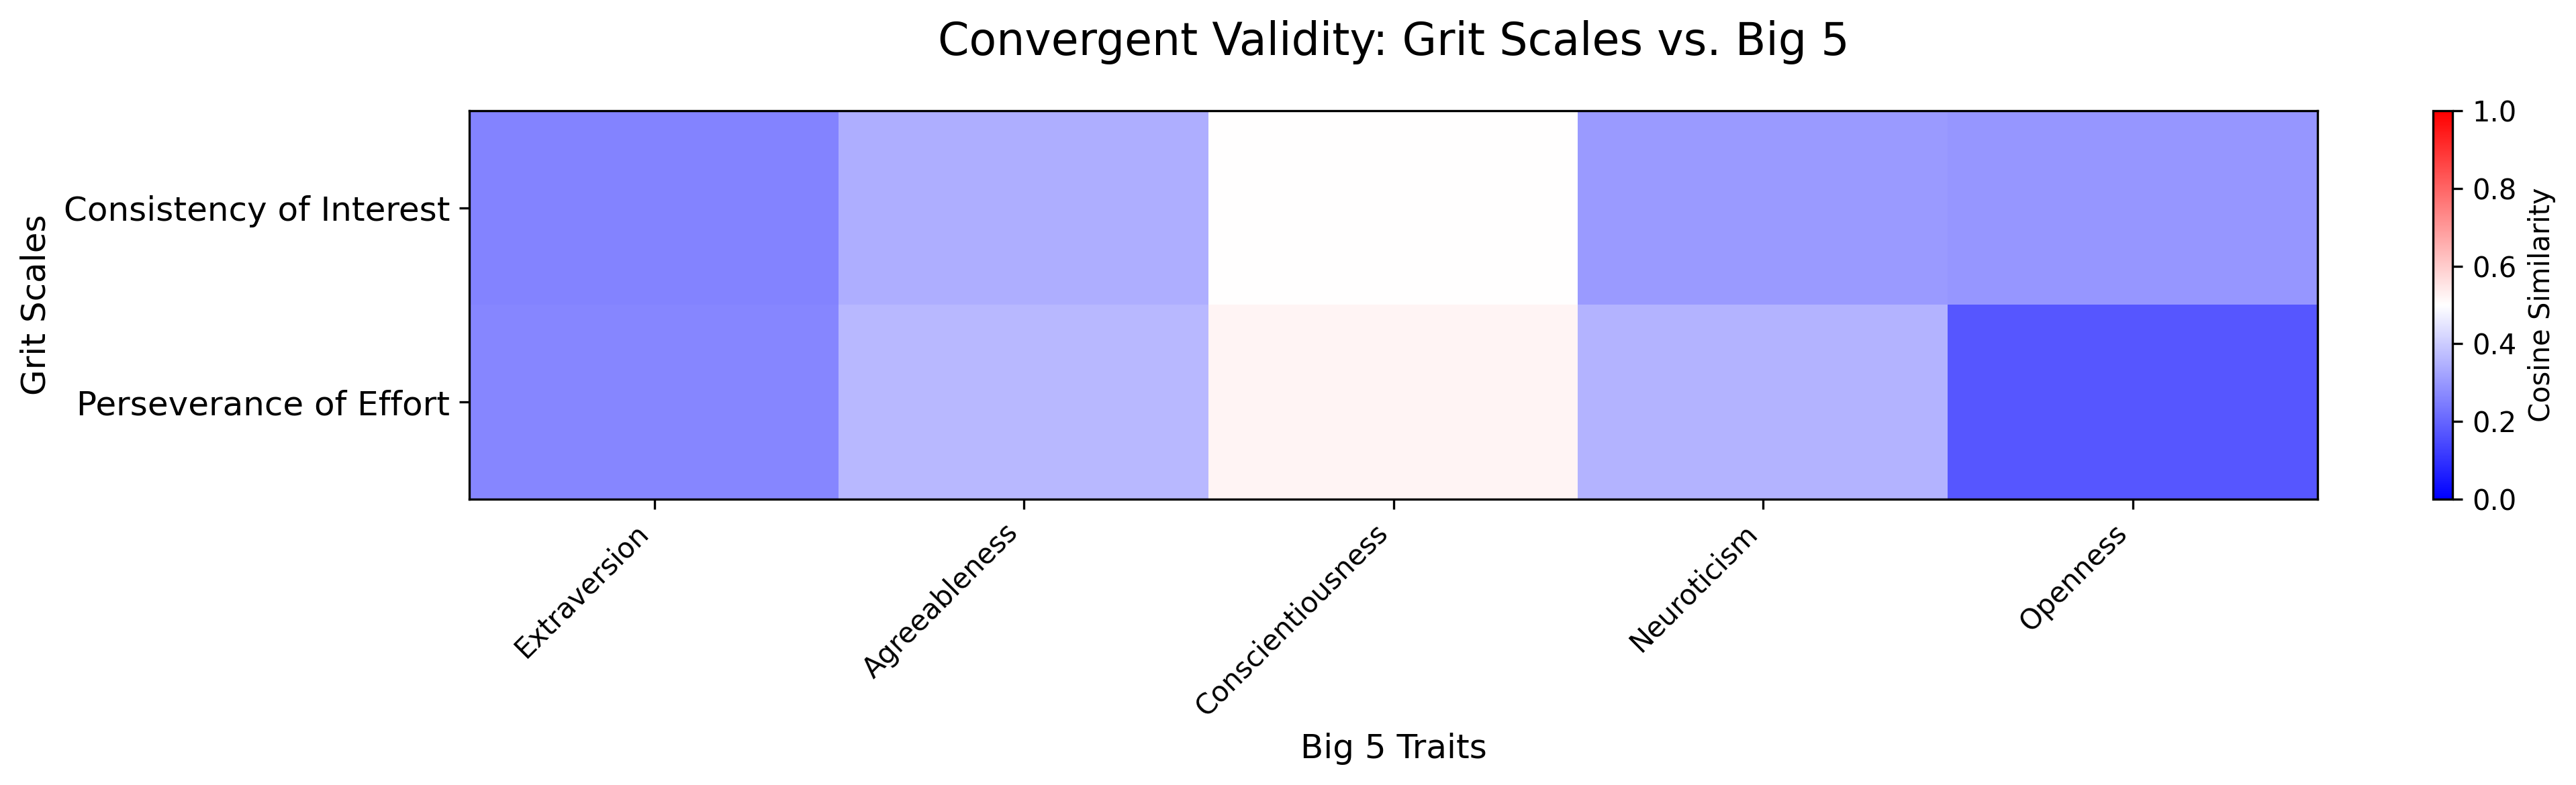

In [5]:
grit_df   = df_mpnet[df_mpnet['framework'] == 'grit']
grit_labels = grit_df['label'].values

sim_g = cosine_similarity(grit_df[embed_cols].values, big5_df[embed_cols].values)

fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
cax = ax.imshow(sim_g, aspect='auto', cmap='bwr', vmin=0, vmax=1)
plt.colorbar(cax, label='Cosine Similarity')
ax.set_xticks(np.arange(len(big5_labels)))
ax.set_xticklabels(big5_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks(np.arange(len(grit_labels)))
ax.set_yticklabels(grit_labels, fontsize=12)
ax.set_title('Convergent Validity: Grit Scales vs. Big 5', fontsize=16, pad=20)
ax.set_xlabel('Big 5 Traits', fontsize=12)
ax.set_ylabel('Grit Scales', fontsize=12)
plt.tight_layout()
plt.savefig('grit_vs_big5_heatmap.jpeg', format='jpeg', dpi=300)
plt.show()

---
# Phase 2 — IPIP Embeddings & FAISS Index
Build a semantic search index over 3,805 validated IPIP personality items. This index is the retrieval backbone for all RAG conditions.

## 2.1 — IPIP Data Loading & OpenAI Embedding
Embed all 3,805 items using `text-embedding-3-small` (1536D) in batches of 100. This takes ~30–40 seconds and costs approximately $0.0006.

In [ ]:
from tqdm import tqdm

items_df = pd.read_csv('TedoneItemAssignmentTable30APR21.csv')
print(f'Loaded {len(items_df)} IPIP items')
print(items_df.head(3))

def get_embeddings_batch(texts):
    response = openai_client.embeddings.create(
        model='text-embedding-3-small',
        input=texts
    )
    return [item.embedding for item in response.data]

embeddings = []
batch_size = 100

print(f'Embedding {len(items_df)} items in batches of {batch_size}...')
for i in tqdm(range(0, len(items_df), batch_size)):
    batch_texts = items_df['text'][i:i+batch_size].tolist()
    try:
        batch_embs = get_embeddings_batch(batch_texts)
        embeddings.extend(batch_embs)
    except Exception as e:
        print(f'\nError on batch {i}: {e}')
        embeddings.extend([None] * len(batch_texts))

items_df['embedding'] = embeddings
print(f'\n✅ Success: {sum(1 for e in embeddings if e is not None)}/{len(items_df)}')

## 2.2 — FAISS Index Construction
Convert the embedding list to a float32 numpy matrix and build a FAISS `IndexFlatL2` for exact nearest-neighbor search.

In [7]:
import faiss

# Filter out any failed embeddings
valid_mask = items_df['embedding'].apply(lambda x: x is not None)
items_df_valid = items_df[valid_mask].reset_index(drop=True)

embedding_matrix = np.array(items_df_valid['embedding'].tolist()).astype('float32')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

dimension = embedding_matrix.shape[1]  # 1536
index = faiss.IndexFlatL2(dimension)
index.add(embedding_matrix)

print(f'✅ FAISS index built with {index.ntotal} vectors')

Embedding matrix shape: (3805, 1536)
✅ FAISS index built with 3805 vectors


---
# Phase 3 — Retrieval Validation
Verify that the FAISS index returns semantically relevant items for our scale definitions before using it in generation.

## 3.1 — RAG Retrieval Quality Check
For each scale, retrieve the top 20 most similar IPIP items. Display results with label breakdown and compute precision, recall, and F1 against a set of expected relevant labels.


Scale: Consistency of Interest
Query: Maintaining focus on a single ambition. Resisting the urge to shift to new projects or obsessions.


                                    label                                             text  distance
                         Non-Perseverance  Have difficulty keeping my attention on a task.    0.9348
                                     ADHD  Have difficulty keeping my attention on a task.    0.9348
                             Cautiousness                         Stick to my chosen path.    1.0608
                              Planfulness                         Stick to my chosen path.    1.0609
 Industriousness/Perseverance/Persistence               Don't get sidetracked when I work.    1.1132
                       Cognitive-Failures          Have difficulty keeping things in mind.    1.1182
                               Depression Had trouble keeping my mind on what I was doing.    1.1191
                        Conscientiousness           Don't put my mind on the task at hand.    1.1262
                               Competence           Don't put my mind on the task at hand. 

                                   label                                        text  distance
Industriousness/Perseverance/Persistence Finish things despite obstacles in the way.    0.7386
                     Emotional Stability                  Readily overcome setbacks.    0.7800
                               Happiness                  Readily overcome setbacks.    0.7800
                           Self-efficacy                  Readily overcome setbacks.    0.7800
                           Vulnerability                  Readily overcome setbacks.    0.7801
                            Forcefulness                  Readily overcome setbacks.    0.7802
                           Hope/Optimism          Remain hopeful despite challenges.    0.9785
                               Diligence       Stop when work becomes too difficult.    0.9909
Industriousness/Perseverance/Persistence                Complete tasks successfully.    1.0091
                            Organization          

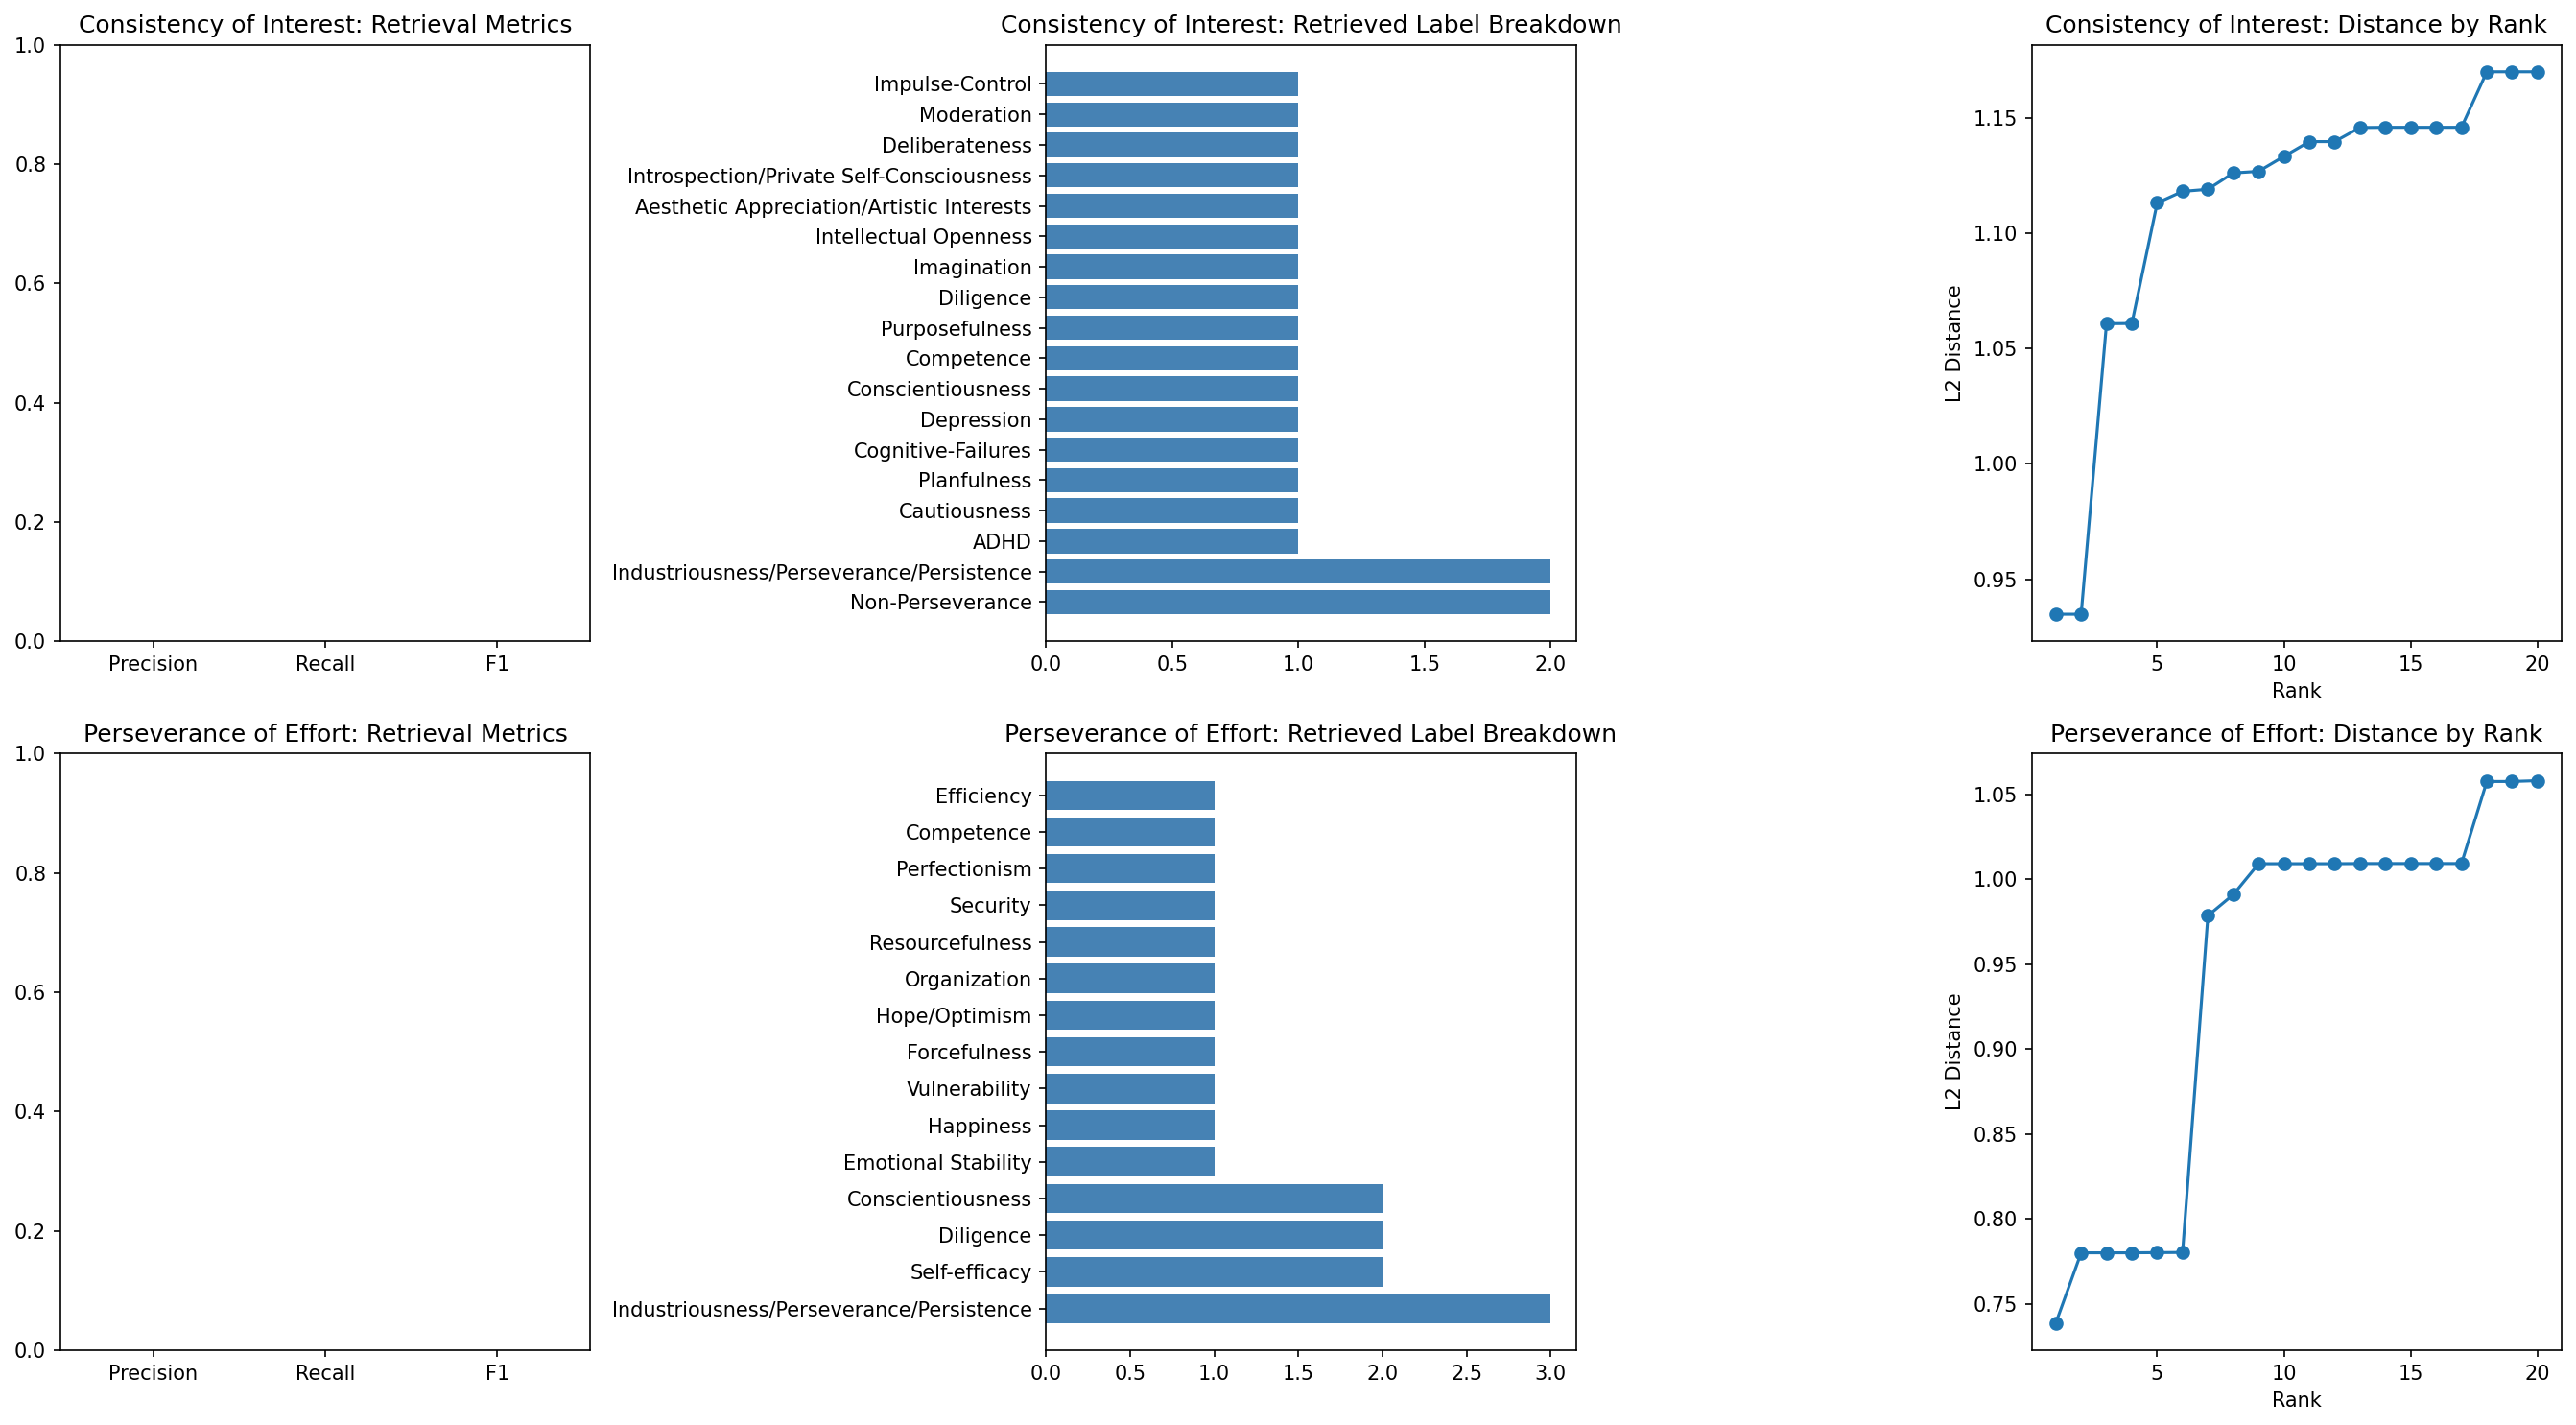

In [8]:
def get_embedding(text):
    """Embed a single query string using text-embedding-3-small."""
    response = openai_client.embeddings.create(
        model='text-embedding-3-small',
        input=[text]
    )
    return response.data[0].embedding

def retrieve_items(query_text, k=20):
    """Retrieve top-k most similar IPIP items for a query."""
    query_emb = np.array([get_embedding(query_text)]).astype('float32')
    distances, indices = index.search(query_emb, k)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        item = items_df_valid.iloc[idx]
        results.append({'label': item['label'], 'text': item['text'], 'distance': round(float(dist), 4)})
    return results

# Expected relevant labels per scale (adjust based on domain knowledge)
EXPECTED_LABELS = {
    'Adaptability':    {'Flexibility', 'Adaptability', 'Openness', 'Resilience'},
    'Exploratoriness': {'Openness', 'Curiosity', 'Intellect', 'Imagination', 'Adventurousness'}
}

fig, axes = plt.subplots(len(SCALES), 3, figsize=(18, 5 * len(SCALES)), dpi=150)

for row_i, (scale_name, scale_desc) in enumerate(SCALES.items()):
    print(f'\n{'='*60}')
    print(f'Scale: {scale_name}')
    print(f'Query: {scale_desc}')
    results = retrieve_items(scale_desc, k=20)
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    retrieved_labels = set(results_df['label'].tolist())
    expected = EXPECTED_LABELS.get(scale_name, set())
    tp = len(retrieved_labels & expected)
    precision = tp / len(retrieved_labels) if retrieved_labels else 0
    recall    = tp / len(expected) if expected else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f'\nPrecision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}')

    ax_metrics, ax_labels, ax_rank = axes[row_i]

    # Chart 1: Metrics
    ax_metrics.bar(['Precision', 'Recall', 'F1'], [precision, recall, f1], color=['steelblue','coral','seagreen'])
    ax_metrics.set_ylim(0, 1)
    ax_metrics.set_title(f'{scale_name}: Retrieval Metrics')

    # Chart 2: Label breakdown
    label_counts = results_df['label'].value_counts()
    ax_labels.barh(label_counts.index, label_counts.values, color='steelblue')
    ax_labels.set_title(f'{scale_name}: Retrieved Label Breakdown')

    # Chart 3: Distance by rank
    ax_rank.plot(range(1, len(results)+1), results_df['distance'], marker='o')
    ax_rank.set_xlabel('Rank')
    ax_rank.set_ylabel('L2 Distance')
    ax_rank.set_title(f'{scale_name}: Distance by Rank')

plt.tight_layout()
plt.show()

---
# Phase 4 — Item Generation: No-RAG
Each model generates items from the scale description alone, with no retrieved examples. 40 items per scale per model.

**Prompt structure:** Short, clear statements, psychometrically reliable and valid, each item measures one construct characteristic, mix of positive and negative keying, distinctly worded, no scale name mentioned.

## 4.1 — No-RAG: Gemini (`gemini-2.5-flash-lite`)
Uses Google AI Studio API. Temperature = 1.0 via `GenerateContentConfig`.

In [ ]:
N_ITEMS = 40
MODEL_LABEL = 'gemini'
GEMINI_MODEL = 'gemini-2.5-flash-lite'

def build_no_rag_prompt(scale_name, scale_desc, n):
    return (
        f'Generate {n} psychometrically reliable and valid personality survey items that measure: {scale_name} — {scale_desc}\n\n'
        'Requirements:\n'
        '- Each item must be ONE short, clear statement\n'
        '- Each item measures ONE and ONLY ONE characteristic of the construct\n'
        '- Do NOT mention the scale name in the item\n'
        '- Mix positively and negatively keyed items\n'
        '- Each item must be CONCISE and DISTINCTLY worded from all other items — no near-duplicates\n'
        'Return ONLY the items, one per line, no numbering, no extra text.'
    )

def generate_gemini(prompt):
    res = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt,
        config=genai_types.GenerateContentConfig(temperature=1.0)
    )
    return res.text.strip()

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} items for {scale_name}...')
    prompt = build_no_rag_prompt(scale_name, scale_desc, N_ITEMS)
    raw = generate_gemini(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'No-RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_no_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_no_rag.csv')
df_out

## 4.2 — No-RAG: GPT-4o-mini
Uses OpenAI API. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'gpt'
GPT_MODEL = 'gpt-4o-mini'

def generate_gpt(prompt):
    res = openai_client.chat.completions.create(
        model=GPT_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=1.0
    )
    return res.choices[0].message.content.strip()

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} items for {scale_name}...')
    prompt = build_no_rag_prompt(scale_name, scale_desc, N_ITEMS)
    raw = generate_gpt(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'No-RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_no_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_no_rag.csv')
df_out

## 4.3 — No-RAG: LLaMA 3.3 70B (Groq)
Uses Groq Cloud API for high-speed inference. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'llama'
LLAMA_MODEL = 'llama-3.3-70b-versatile'

def generate_llama(prompt):
    res = groq_client.chat.completions.create(
        model=LLAMA_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=1.0
    )
    return res.choices[0].message.content.strip()

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} items for {scale_name}...')
    prompt = build_no_rag_prompt(scale_name, scale_desc, N_ITEMS)
    raw = generate_llama(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'No-RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_no_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_no_rag.csv')
df_out

## 4.4 — No-RAG: DeepSeek-R1 8B (Ollama / Local)
Runs entirely on local M-series Mac. Strips `<think>...</think>` reasoning tags from output. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'deepseek'
DEEPSEEK_MODEL = 'deepseek-r1:8b'

def generate_deepseek(prompt):
    res = ollama.chat(
        model=DEEPSEEK_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        options={'temperature': 1.0}
    )
    content = res['message']['content']
    # Strip chain-of-thought reasoning tags
    clean = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
    return clean

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} items for {scale_name}...')
    prompt = build_no_rag_prompt(scale_name, scale_desc, N_ITEMS)
    raw = generate_deepseek(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'No-RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_no_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_no_rag.csv')
df_out

---
# Phase 5 — Item Generation: RAG
Each model receives 10 semantically similar IPIP items as context before generating. Context is retrieved from the FAISS index built in Phase 2.

## RAG Context Helper (shared)
Retrieve top-k IPIP items for a scale description and format them as a prompt context block.

In [ ]:
def get_rag_context(scale_desc, k=10):
    """Retrieve top-k IPIP items and format as context string."""
    query_emb = np.array([get_embedding(scale_desc)]).astype('float32')
    distances, indices = index.search(query_emb, k)
    context_lines = []
    for idx in indices[0]:
        item = items_df_valid.iloc[idx]
        context_lines.append(f'[{item["label"]}] {item["text"]}')
    return '\n'.join(context_lines)

def build_rag_prompt(scale_name, scale_desc, context, n):
    return (
        f'Below are validated personality test items as style and quality examples:\n{context}\n\n'
        f'Generate {n} NEW psychometrically reliable and valid items that measure: {scale_name} — {scale_desc}\n\n'
        'Requirements:\n'
        '- Each item must be ONE short, clear statement\n'
        '- Each item measures ONE and ONLY ONE characteristic of the construct\n'
        '- Do NOT mention the scale name in the item\n'
        '- Mix positively and negatively keyed items\n'
        '- Each item must be CONCISE and DISTINCTLY worded from all other items and the examples — no near-duplicates\n'
        'Return ONLY the items, one per line, no numbering, no extra text.'
    )

print('✅ RAG context helper ready.')

## 5.1 — RAG: Gemini (`gemini-2.5-flash-lite`)
Context = 10 FAISS-retrieved IPIP items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'gemini'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} RAG items for {scale_name}...')
    context = get_rag_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_gemini(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_rag.csv')
df_out

## 5.2 — RAG: GPT-4o-mini
Context = 10 FAISS-retrieved IPIP items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'gpt'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} RAG items for {scale_name}...')
    context = get_rag_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_gpt(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_rag.csv')
df_out

## 5.3 — RAG: LLaMA 3.3 70B (Groq)
Context = 10 FAISS-retrieved IPIP items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'llama'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} RAG items for {scale_name}...')
    context = get_rag_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_llama(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_rag.csv')
df_out

## 5.4 — RAG: DeepSeek-R1 8B (Ollama / Local)
Context = 10 FAISS-retrieved IPIP items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'deepseek'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} RAG items for {scale_name}...')
    context = get_rag_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_deepseek(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_rag.csv')
df_out

---
# Phase 6 — Item Generation: Re-Ranked RAG
Improve retrieval quality by first fetching k×10 candidates from FAISS, then re-ranking with a cross-encoder to select the most semantically relevant context items.

## 6.0 — Cross-Encoder Setup (shared)
Load `ms-marco-MiniLM-L-6-v2` cross-encoder and define the `get_reranked_context()` helper. Run once before the generation chunks.

In [18]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def get_reranked_context(scale_desc, k=10, overretrieve_factor=10):
    """FAISS retrieves k*overretrieve_factor candidates, cross-encoder re-ranks to top k."""
    query_emb = np.array([get_embedding(scale_desc)]).astype('float32')
    n_candidates = k * overretrieve_factor
    distances, indices = index.search(query_emb, n_candidates)

    candidates = [items_df_valid.iloc[idx]['text'] for idx in indices[0]]
    pairs = [[scale_desc, c] for c in candidates]
    scores = cross_encoder.predict(pairs)

    # Sort by score descending, take top k
    ranked = sorted(zip(scores, indices[0]), key=lambda x: x[0], reverse=True)[:k]
    context_lines = []
    for score, idx in ranked:
        item = items_df_valid.iloc[idx]
        context_lines.append(f'[{item["label"]}] {item["text"]}')
    return '\n'.join(context_lines)

print('✅ Cross-encoder loaded and re-rank helper ready.')


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9668.54it/s]


BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Cross-encoder loaded and re-rank helper ready.


## 6.1 — Re-Ranked RAG: Gemini (`gemini-2.5-flash-lite`)
FAISS retrieves 100 candidates → cross-encoder selects top 10 → Gemini generates items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'gemini'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} re-ranked RAG items for {scale_name}...')
    context = get_reranked_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_gemini(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'Re-Ranked RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_reranked_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_reranked_rag.csv')
df_out

## 6.2 — Re-Ranked RAG: GPT-4o-mini
FAISS retrieves 100 candidates → cross-encoder selects top 10 → GPT-4o-mini generates items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'gpt'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} re-ranked RAG items for {scale_name}...')
    context = get_reranked_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_gpt(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'Re-Ranked RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_reranked_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_reranked_rag.csv')
df_out

## 6.3 — Re-Ranked RAG: LLaMA 3.3 70B (Groq)
FAISS retrieves 100 candidates → cross-encoder selects top 10 → LLaMA generates items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'llama'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} re-ranked RAG items for {scale_name}...')
    context = get_reranked_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_llama(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'Re-Ranked RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_reranked_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_reranked_rag.csv')
df_out

## 6.4 — Re-Ranked RAG: DeepSeek-R1 8B (Ollama / Local)
FAISS retrieves 100 candidates → cross-encoder selects top 10 → DeepSeek generates items. Temperature = 1.0.

In [ ]:
MODEL_LABEL = 'deepseek'

results = []
for scale_name, scale_desc in SCALES.items():
    print(f'Generating {N_ITEMS} re-ranked RAG items for {scale_name}...')
    context = get_reranked_context(scale_desc, k=10)
    prompt = build_rag_prompt(scale_name, scale_desc, context, N_ITEMS)
    raw = generate_deepseek(prompt)
    items = [line.strip() for line in raw.split('\n') if line.strip()][:N_ITEMS]
    for item in items:
        results.append({'Scale': scale_name, 'Model': MODEL_LABEL, 'Condition': 'Re-Ranked RAG', 'Item_Text': item})
    print(f'  → {len(items)} items saved')

df_out = pd.DataFrame(results)
df_out.to_csv(f'items_{MODEL_LABEL}_reranked_rag.csv', index=False)
print(f'\n✅ Saved to items_{MODEL_LABEL}_reranked_rag.csv')
df_out

---
# Phase 7 — Master CSV & Quality Evaluation
Merge all per-model outputs into a single dataset, then evaluate item quality by computing cosine similarity between each generated item and its scale definition.

## 7.1 — Merge to Master CSV
Glob all `items_*.csv` files and combine into `master_items.csv` with columns: `Scale`, `Model`, `Condition`, `Item_Text`.

In [ ]:
import glob

all_files = glob.glob('items_*.csv')
print(f'Found {len(all_files)} files: {all_files}')

dfs = [pd.read_csv(f) for f in all_files]
master_df = pd.concat(dfs, ignore_index=True)
master_df.to_csv('master_items.csv', index=False)

print(f'\n✅ master_items.csv saved: {len(master_df)} total items')
print(master_df.groupby(['Scale', 'Model', 'Condition']).size().reset_index(name='count').to_string(index=False))

## 7.2 — Cosine Similarity Quality Evaluation
Embed each generated item and compute cosine similarity to its scale definition embedding. Higher similarity = better semantic alignment with the construct. Visualized as boxplots grouped by Model × Condition.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

SCALES = {
    'Consistency of Interest': 'Maintaining focus on a single ambition. Resisting the urge to shift to new projects or obsessions.',
    'Perseverance of Effort': 'Sustaining hard work through setbacks. Finishing initiated tasks despite difficulties.'
}

# Rebuild get_embedding if missing
import os
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def get_embedding(text, model="text-embedding-3-small"):
    return openai_client.embeddings.create(input=[text], model=model).data[0].embedding

def get_embeddings_batch(texts, model="text-embedding-3-small", batch_size=100):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        resp = openai_client.embeddings.create(input=texts[i:i+batch_size], model=model)
        all_embs.extend([d.embedding for d in resp.data])
    return all_embs

print("✓ Ready")


Embedding 940 generated items...


100%|██████████| 10/10 [00:05<00:00,  1.79it/s]


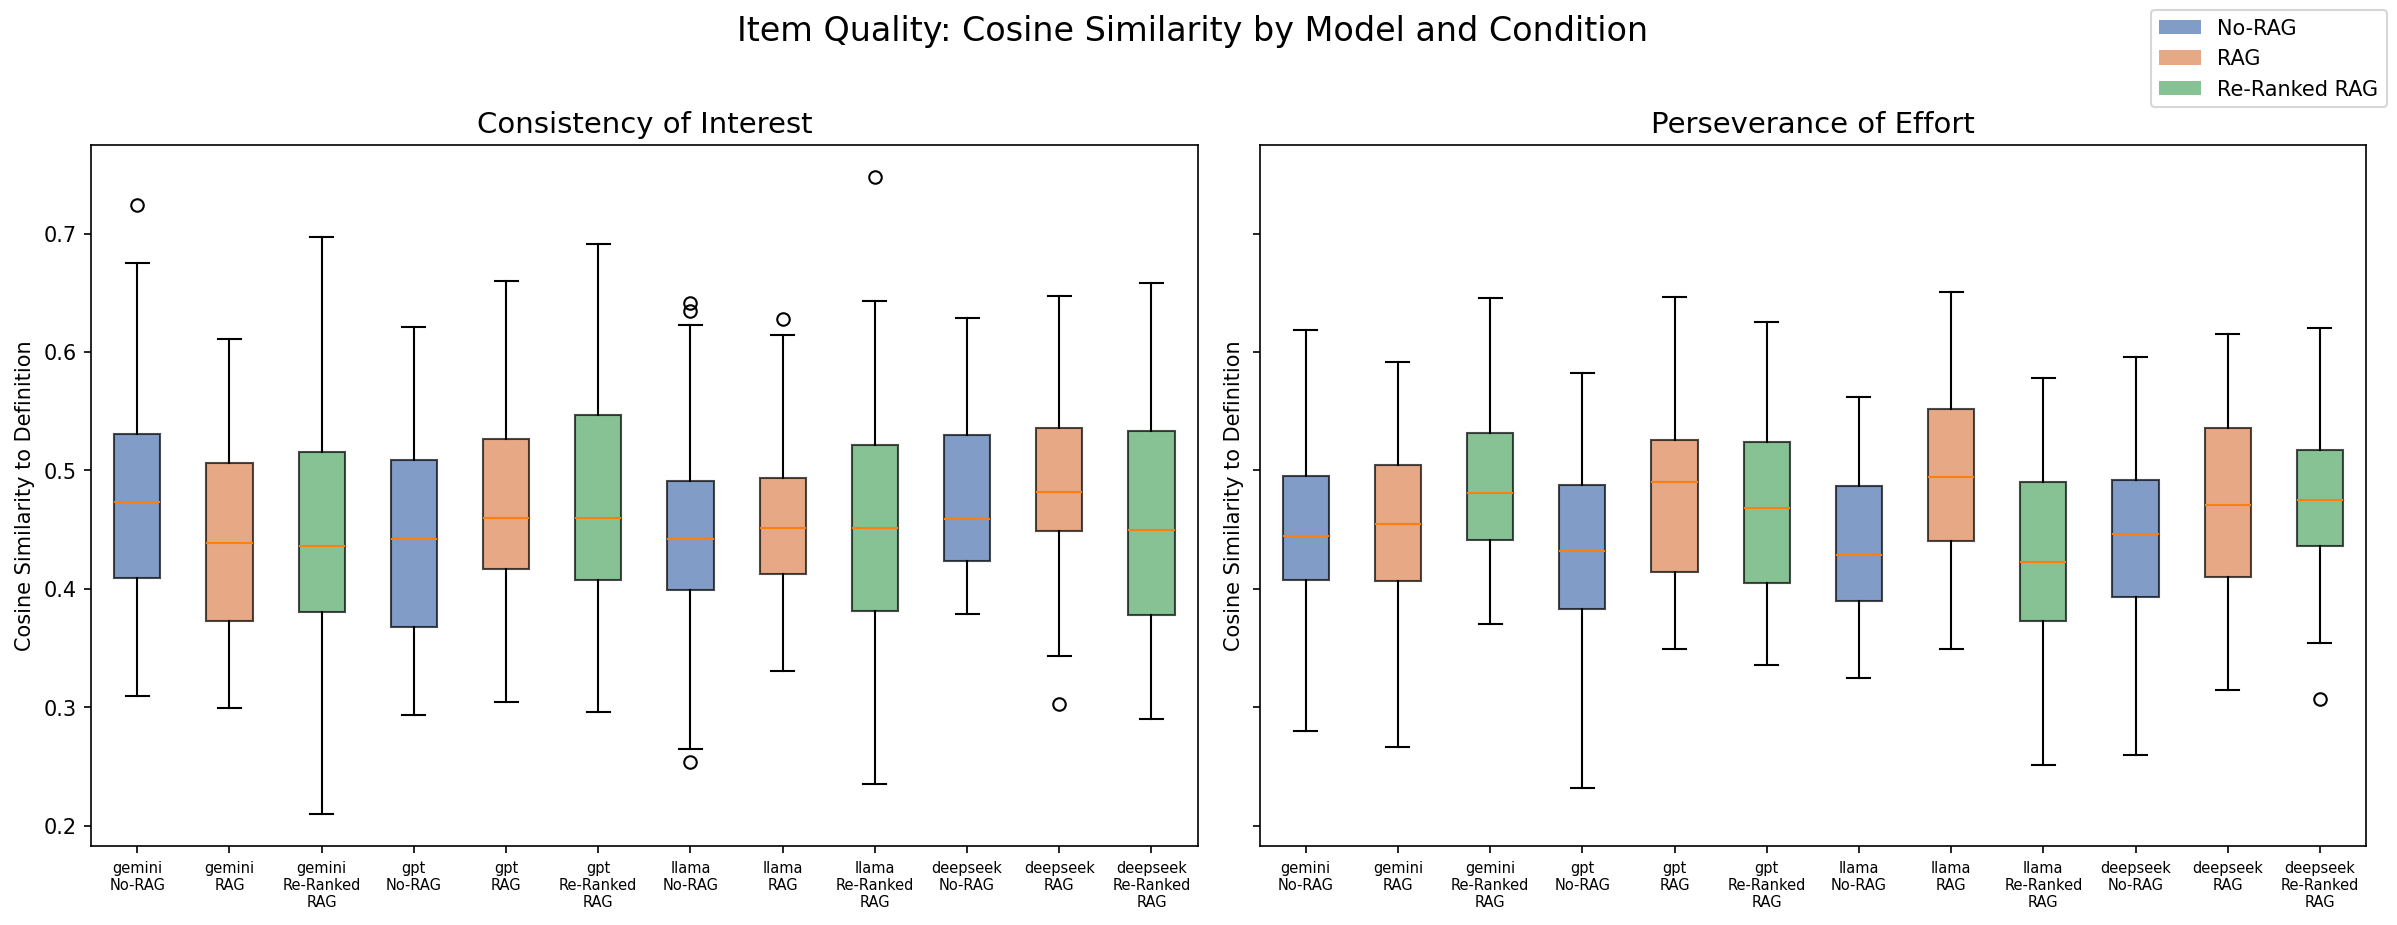


Mean similarity by Model × Condition:
Scale                    Model     Condition    
Consistency of Interest  deepseek  No-RAG           0.480
                                   RAG              0.487
                                   Re-Ranked RAG    0.450
                         gemini    No-RAG           0.480
                                   RAG              0.446
                                   Re-Ranked RAG    0.455
                         gpt       No-RAG           0.440
                                   RAG              0.471
                                   Re-Ranked RAG    0.472
                         llama     No-RAG           0.447
                                   RAG              0.460
                                   Re-Ranked RAG    0.456
Perseverance of Effort   deepseek  No-RAG           0.446
                                   RAG              0.472
                                   Re-Ranked RAG    0.472
                         gemini    No-RAG 

In [13]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Embed scale definitions
scale_def_embs = {name: np.array(get_embedding(desc)) for name, desc in SCALES.items()}

# Embed all generated items in batches
print(f'Embedding {len(master_df)} generated items...')
all_texts = master_df['Item_Text'].tolist()
item_embeddings = []
for i in tqdm(range(0, len(all_texts), 100)):
    batch = all_texts[i:i+100]
    item_embeddings.extend(get_embeddings_batch(batch))

master_df['embedding'] = item_embeddings

# Compute cosine similarity per item vs. its scale definition
def compute_similarity(row):
    item_emb = np.array(row['embedding']).reshape(1, -1)
    def_emb  = scale_def_embs[row['Scale']].reshape(1, -1)
    return float(cos_sim(item_emb, def_emb)[0][0])

master_df['cosine_sim'] = master_df.apply(compute_similarity, axis=1)

# Boxplot: Model × Condition, split by Scale
fig, axes = plt.subplots(1, len(SCALES), figsize=(16, 6), dpi=150, sharey=True)
conditions = ['No-RAG', 'RAG', 'Re-Ranked RAG']
models = ['gemini', 'gpt', 'llama', 'deepseek']
colors = {'No-RAG': '#4c72b0', 'RAG': '#dd8452', 'Re-Ranked RAG': '#55a868'}

for ax, scale_name in zip(axes, SCALES):
    scale_data = master_df[master_df['Scale'] == scale_name]
    plot_data = []
    plot_labels = []
    for model in models:
        for cond in conditions:
            subset = scale_data[(scale_data['Model'] == model) & (scale_data['Condition'] == cond)]['cosine_sim']
            plot_data.append(subset.tolist())
            plot_labels.append(f'{model}\n{cond.replace(" ", chr(10))}')

    bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)
    for i, (patch, cond) in enumerate(zip(bp['boxes'], conditions * len(models))):
        patch.set_facecolor(colors[cond])
        patch.set_alpha(0.7)
    ax.set_title(f'{scale_name}', fontsize=14)
    ax.set_ylabel('Cosine Similarity to Definition', fontsize=10)
    ax.tick_params(axis='x', labelsize=7)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[c], alpha=0.7, label=c) for c in conditions]
fig.legend(handles=legend_handles, loc='upper right', fontsize=10)
plt.suptitle('Item Quality: Cosine Similarity by Model and Condition', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('quality_comparison.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

print('\nMean similarity by Model × Condition:')
print(master_df.groupby(['Scale','Model','Condition'])['cosine_sim'].mean().round(3).to_string())

---
# Phase 8 — Pseudo Factor Analysis
Evaluate the latent factor structure of generated items using embedding-based cosine similarity as a correlation substitute, Exploratory Factor Analysis (EFA) with oblique rotation, and semantic discrimination scores.

**Conditions:** 4 models × 3 generation methods = 12 conditions  
**Items per condition:** ~80 (40 CI + 40 PE)  
**EFA:** 2 factors, Maximum Likelihood extraction, Oblimin rotation

## 8.1 — Setup & Similarity Matrices
Reuse OpenAI embeddings from Phase 7, build a cosine similarity matrix for each condition, and regularise it to be positive-definite before factor extraction.

In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.metrics.pairwise import cosine_similarity
from factor_analyzer.rotator import Rotator   # only the rotator — avoids sklearn compat issue

# ── Custom PAF (Principal Axis Factoring) ─────────────────────────────────────
def principal_axis_factoring(R, n_factors=2, max_iter=200, tol=1e-7):
    """Iterative PAF on a correlation matrix R. Returns pattern loadings (n x n_factors)."""
    n = len(R)
    R_mod = R.copy()
    try:
        R_inv = np.linalg.inv(R)
        smc = np.clip(1 - 1 / np.diag(R_inv), 0, 1)
    except np.linalg.LinAlgError:
        smc = np.full(n, 0.5)

    for _ in range(max_iter):
        np.fill_diagonal(R_mod, smc)
        eigvals, eigvecs = np.linalg.eigh(R_mod)
        idx = np.argsort(eigvals)[::-1]
        eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
        eig_pos = np.maximum(eigvals[:n_factors], 0)
        loadings = eigvecs[:, :n_factors] * np.sqrt(eig_pos)
        new_smc = np.clip(np.sum(loadings ** 2, axis=1), 0, 1)
        if np.max(np.abs(new_smc - smc)) < tol:
            break
        smc = new_smc
    return loadings

def run_efa(R, n_factors=2):
    """PAF extraction + Oblimin rotation."""
    L = principal_axis_factoring(R, n_factors)
    rotator = Rotator(method='oblimin')
    return rotator.fit_transform(L)

# ── Reuse master_df + embeddings from Phase 7 ────────────────────────────────
assert 'embedding' in master_df.columns, "Run Phase 7 first to populate master_df['embedding']"
master_df['Condition_Key'] = master_df['Model'] + ' × ' + master_df['Condition']

# Stack OpenAI 1536-D embeddings and L2-normalise
all_embs = np.vstack(master_df['embedding'].values).astype(np.float32)
norms = np.linalg.norm(all_embs, axis=1, keepdims=True)
all_embs /= np.where(norms == 0, 1, norms)

master_df['emb_idx'] = range(len(master_df))

# ── Construct-definition embeddings (reuse from Phase 7) ─────────────────────
SCALE_DEFS = {
    'Consistency of Interest':
        'Maintaining focus on a single ambition. Resisting the urge to shift to new projects or obsessions.',
    'Perseverance of Effort':
        'Sustaining hard work through setbacks. Finishing initiated tasks despite difficulties.'
}
SCALE_ORDER = list(SCALE_DEFS.keys())   # [CI, PE]

# Reuse scale_def_embs computed in Phase 7 (avoids 2 extra API calls)
CI_DEF_EMB = np.array(scale_def_embs['Consistency of Interest'], dtype=np.float32)
PE_DEF_EMB = np.array(scale_def_embs['Perseverance of Effort'],  dtype=np.float32)
CI_DEF_EMB /= np.linalg.norm(CI_DEF_EMB)
PE_DEF_EMB /= np.linalg.norm(PE_DEF_EMB)

# ── Helper: regularise matrix to be positive-definite ────────────────────────
def regularise_corr(mat):
    """Shift smallest eigenvalue to ≥ 0.001, then renormalise diagonal to 1."""
    min_eig = np.linalg.eigvalsh(mat).min()
    if min_eig < 0.001:
        mat = mat + (abs(min_eig) + 0.01) * np.eye(len(mat))
        d = np.sqrt(np.diag(mat))
        mat = mat / np.outer(d, d)
    return mat

CROSS_THR = 0.30    # |loading| threshold for cross-loading / weak flag
DISC_TOP_K = 20     # items per scale kept for filtered EFA re-run

# ── Build per-condition similarity matrices ───────────────────────────────────
cond_data = {}
for cond_key in sorted(master_df['Condition_Key'].unique()):
    sub  = master_df[master_df['Condition_Key'] == cond_key].reset_index(drop=True)
    embs = all_embs[sub['emb_idx'].values]
    sim  = regularise_corr(cosine_similarity(embs))
    cond_data[cond_key] = {
        'sub':    sub,
        'embs':   embs,
        'sim':    sim,
        'labels': sub['Scale'].values,
    }
    print(f"  {cond_key:30s}  n={len(sub):3d}  sim=[{sim.min():.3f}, {sim.max():.3f}]")

print("\nSimilarity matrices ready.")


  deepseek × No-RAG               n= 80  sim=[0.203, 1.000]
  deepseek × RAG                  n= 79  sim=[0.164, 1.000]
  deepseek × Re-Ranked RAG        n= 80  sim=[0.103, 1.000]
  gemini × No-RAG                 n= 80  sim=[0.182, 1.000]
  gemini × RAG                    n= 80  sim=[0.210, 1.000]
  gemini × Re-Ranked RAG          n= 80  sim=[0.149, 1.000]
  gpt × No-RAG                    n= 80  sim=[0.110, 1.000]
  gpt × RAG                       n= 80  sim=[0.170, 1.000]
  gpt × Re-Ranked RAG             n= 80  sim=[0.210, 1.000]
  llama × No-RAG                  n= 77  sim=[0.140, 1.000]
  llama × RAG                     n= 72  sim=[0.037, 1.000]
  llama × Re-Ranked RAG           n= 72  sim=[0.028, 1.000]

Similarity matrices ready.


## 8.2 — Exploratory Factor Analysis per Condition
For each condition: extract 2 factors (ML → PA fallback), apply Oblimin rotation, align factors to constructs by average absolute loading, then flag cross-loading and weak items.

**DAAL (Dominant Average Absolute Loading):** normalise each item's factor loadings by the mean loading of confirmed items on that factor before assigning — accounts for scale differences between factors.

In [15]:
records = []

for cond_key, cd in cond_data.items():
    sub    = cd['sub']
    embs   = cd['embs']
    sim    = cd['sim']
    labels = cd['labels']
    n      = len(sub)

    ci_mask = labels == 'Consistency of Interest'
    pe_mask = labels == 'Perseverance of Effort'

    # ── Step 2  PAF + Oblimin EFA ─────────────────────────────────────────────
    try:
        loadings = run_efa(sim)   # (n, 2)
    except Exception as exc:
        print(f"  [{cond_key}] EFA failed: {exc}")
        continue

    # ── Step 3a  Align factors to constructs ─────────────────────────────────
    abs_load = np.abs(loadings)
    ci_f0 = np.mean(abs_load[ci_mask, 0])
    ci_f1 = np.mean(abs_load[ci_mask, 1])
    ci_fac = 0 if ci_f0 >= ci_f1 else 1
    pe_fac = 1 - ci_fac

    # ── Step 3b  Argmax assignment ───────────────────────────────────────────
    argmax_fac   = np.argmax(abs_load, axis=1)
    argmax_scale = np.where(argmax_fac == ci_fac,
                            'Consistency of Interest',
                            'Perseverance of Effort')

    # ── Step 3c  DAAL assignment ─────────────────────────────────────────────
    ci_daal_mean = np.mean(abs_load[ci_mask, ci_fac]) + 1e-9
    pe_daal_mean = np.mean(abs_load[pe_mask, pe_fac]) + 1e-9

    daal_scale = np.where(
        abs_load[:, ci_fac] / ci_daal_mean >= abs_load[:, pe_fac] / pe_daal_mean,
        'Consistency of Interest', 'Perseverance of Effort'
    )

    # ── Step 3d  Problematic items ───────────────────────────────────────────
    cross_loading = (abs_load[:, 0] >= CROSS_THR) & (abs_load[:, 1] >= CROSS_THR)
    weak          = abs_load.max(axis=1) < CROSS_THR
    unassigned    = cross_loading | weak

    # ── Step 4  Residual matrix ──────────────────────────────────────────────
    reproduced    = loadings @ loadings.T
    residuals     = sim - reproduced
    np.fill_diagonal(residuals, 0)
    residual_rmse = float(np.sqrt((residuals ** 2).mean()))

    # ── Step 5  Metrics ──────────────────────────────────────────────────────
    pct_argmax = (argmax_scale == labels).mean() * 100
    pct_daal   = (daal_scale   == labels).mean() * 100

    # ── Step 6  Semantic discrimination ──────────────────────────────────────
    sim_ci = embs @ CI_DEF_EMB
    sim_pe = embs @ PE_DEF_EMB
    target_sim = np.where(ci_mask, sim_ci, sim_pe)
    other_sim  = np.where(ci_mask, sim_pe, sim_ci)
    disc1 = target_sim - other_sim

    # ── Step 6b  Filtered EFA on top-DISC_TOP_K items per scale ──────────────
    ci_idx = np.where(ci_mask)[0]
    pe_idx = np.where(pe_mask)[0]
    ci_top = ci_idx[np.argsort(disc1[ci_mask])[-DISC_TOP_K:]]
    pe_top = pe_idx[np.argsort(disc1[pe_mask])[-DISC_TOP_K:]]
    sel    = np.concatenate([ci_top, pe_top])

    pct_topk = None
    try:
        sub_sim  = regularise_corr(sim[np.ix_(sel, sel)])
        true_sel = labels[sel]
        ld2      = run_efa(sub_sim)
        abs2     = np.abs(ld2)
        ci_f0_2  = np.mean(abs2[true_sel == 'Consistency of Interest', 0])
        ci_f1_2  = np.mean(abs2[true_sel == 'Consistency of Interest', 1])
        ci2_fac  = 0 if ci_f0_2 >= ci_f1_2 else 1
        asgn2    = np.where(np.argmax(abs2, axis=1) == ci2_fac,
                            'Consistency of Interest', 'Perseverance of Effort')
        pct_topk = (asgn2 == true_sel).mean() * 100
    except Exception:
        pass

    records.append(dict(
        Condition          = cond_key,
        n_items            = n,
        ci_factor          = f'F{ci_fac + 1}',
        pct_correct_argmax = round(pct_argmax, 1),
        pct_correct_DAAL   = round(pct_daal, 1),
        n_cross_loading    = int(cross_loading.sum()),
        n_weak             = int(weak.sum()),
        n_unassigned       = int(unassigned.sum()),
        mean_disc          = round(float(disc1.mean()), 4),
        sd_disc            = round(float(disc1.std()),  4),
        residual_rmse      = round(residual_rmse, 4),
        pct_correct_topK   = round(pct_topk, 1) if pct_topk is not None else None,
        _loadings          = loadings,
        _labels            = labels,
        _cross             = cross_loading,
        _weak              = weak,
        _disc1             = disc1,
        _ci_fac            = ci_fac,
        _pe_fac            = pe_fac,
    ))
    print(f"  {cond_key:30s}  argmax={pct_argmax:.1f}%  DAAL={pct_daal:.1f}%  "
          f"cross={cross_loading.sum()}  weak={weak.sum()}")

summary_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                            for r in records])
print("\n── EFA complete ──")
print(summary_df[['Condition','pct_correct_argmax','pct_correct_DAAL',
                   'n_cross_loading','n_weak','residual_rmse','pct_correct_topK']].to_string(index=False))


  deepseek × No-RAG               argmax=97.5%  DAAL=97.5%  cross=6  weak=0
  deepseek × RAG                  argmax=92.4%  DAAL=89.9%  cross=13  weak=0
  deepseek × Re-Ranked RAG        argmax=93.8%  DAAL=93.8%  cross=8  weak=0
  gemini × No-RAG                 argmax=51.2%  DAAL=50.0%  cross=2  weak=0
  gemini × RAG                    argmax=52.5%  DAAL=52.5%  cross=5  weak=0
  gemini × Re-Ranked RAG          argmax=82.5%  DAAL=86.2%  cross=6  weak=0
  gpt × No-RAG                    argmax=90.0%  DAAL=90.0%  cross=10  weak=0
  gpt × RAG                       argmax=85.0%  DAAL=83.8%  cross=17  weak=0
  gpt × Re-Ranked RAG             argmax=55.0%  DAAL=55.0%  cross=7  weak=0
  llama × No-RAG                  argmax=75.3%  DAAL=76.6%  cross=9  weak=0
  llama × RAG                     argmax=97.2%  DAAL=97.2%  cross=6  weak=0
  llama × Re-Ranked RAG           argmax=98.6%  DAAL=98.6%  cross=5  weak=0

── EFA complete ──
               Condition  pct_correct_argmax  pct_correct_DAAL  n

## 8.3 — Factor Loading Plots & Summary
Scatter plots of Factor-CI vs Factor-PE loadings for each condition. Color = true scale (blue CI / orange PE). Shape: circle = clean, × = cross-loading, square = weak.

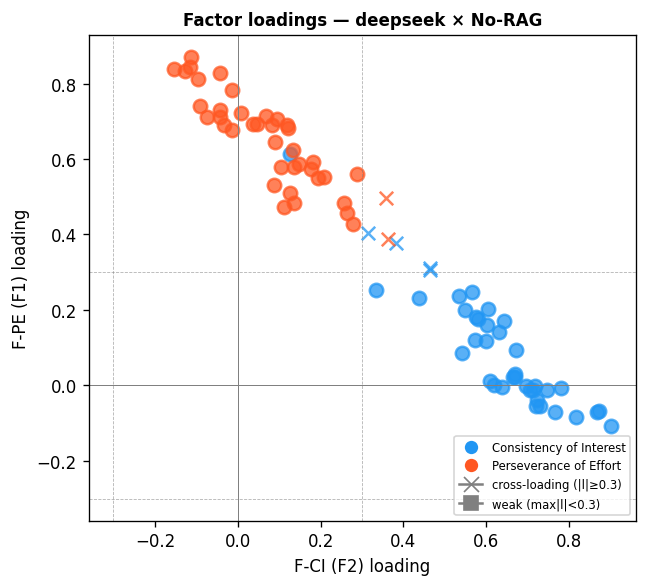

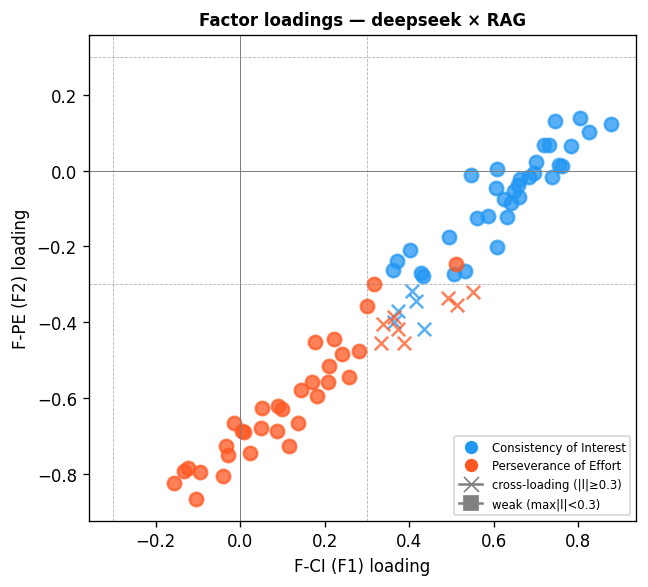

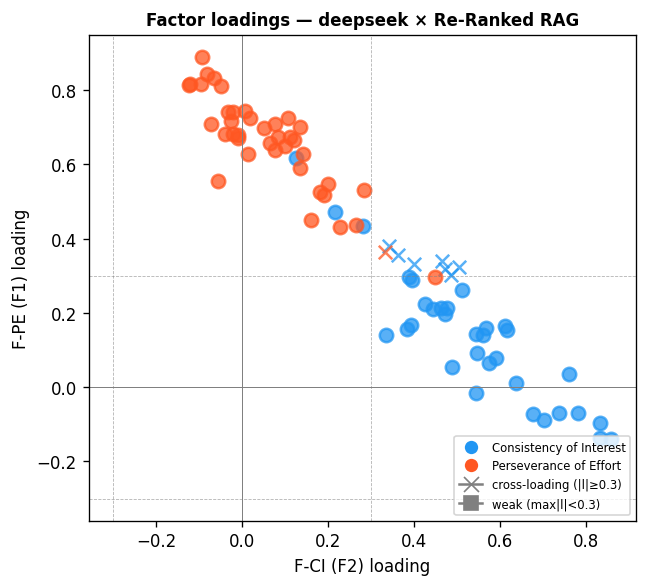

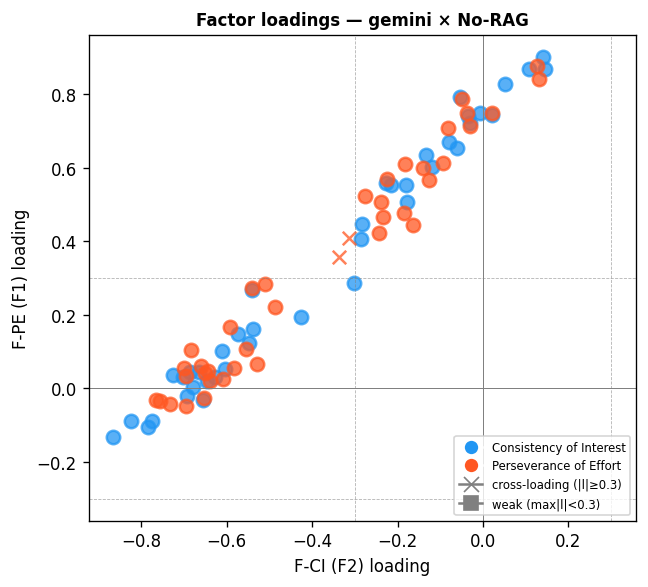

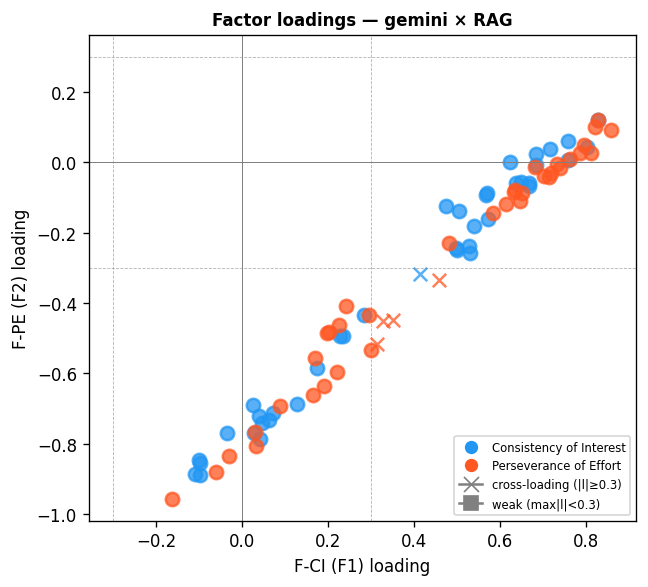

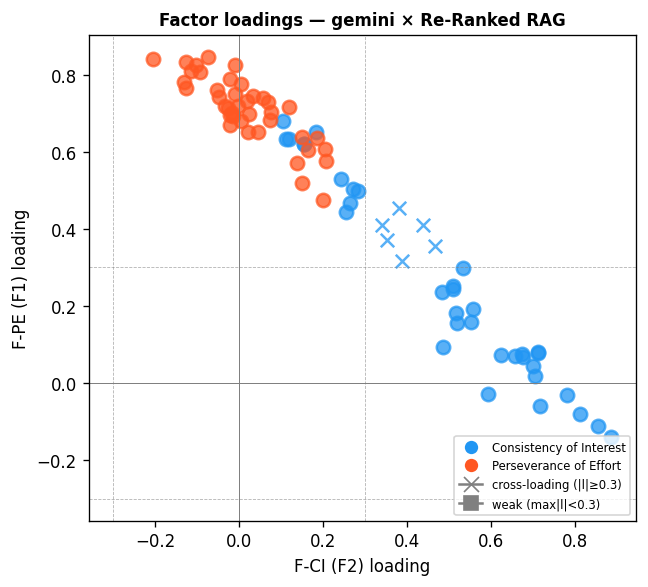

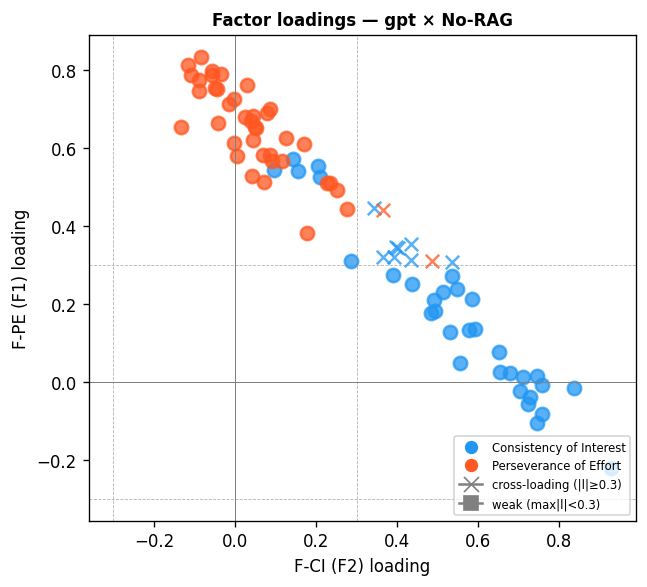

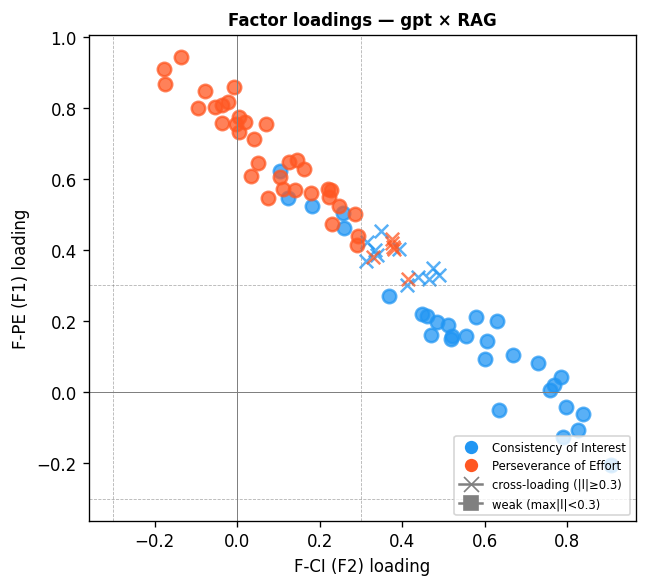

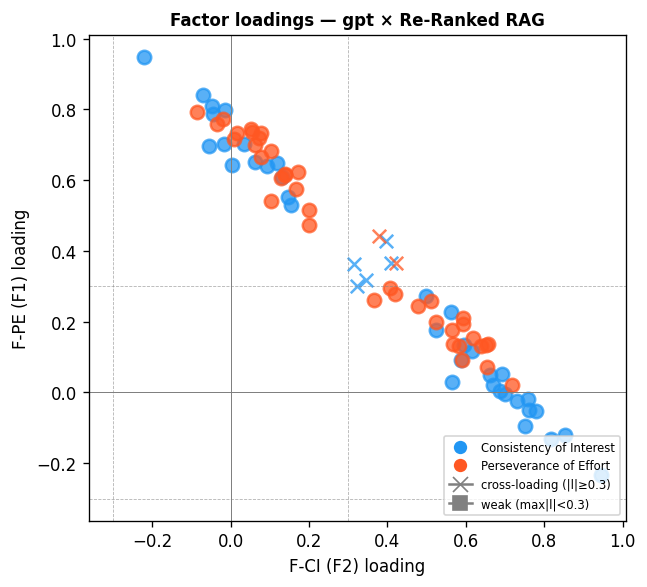

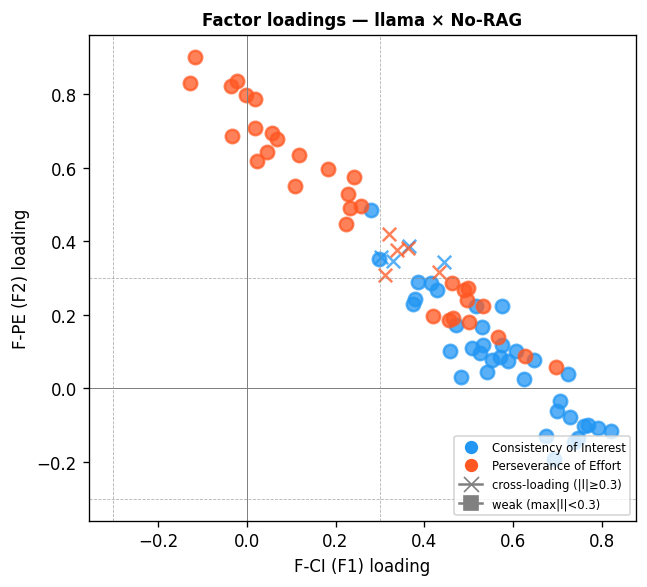

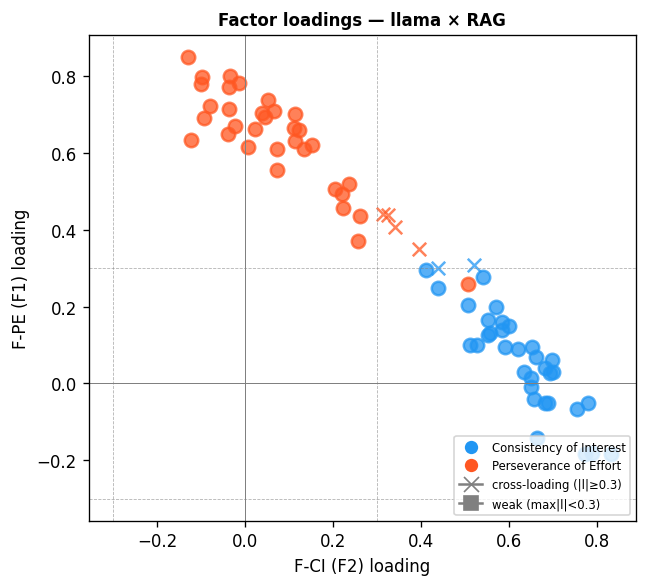

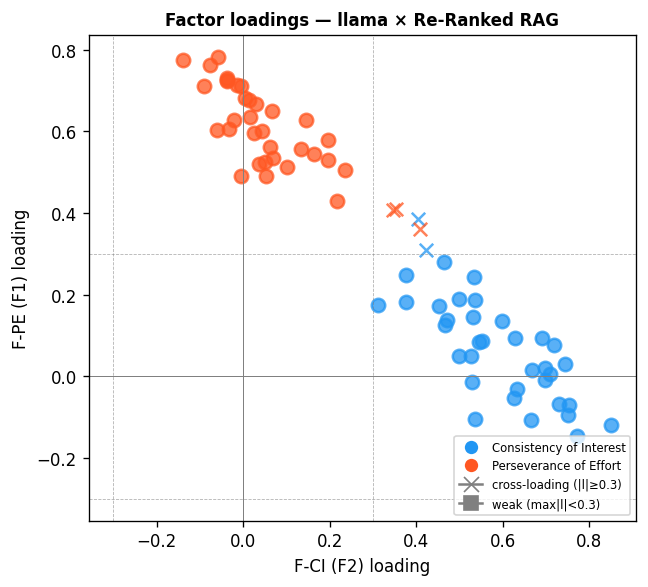


── EFA Summary ──


,Condition,n_items,pct_correct_argmax,pct_correct_DAAL,n_cross_loading,n_weak,n_unassigned,mean_disc,residual_rmse,pct_correct_topK
0,llama × Re-Ranked RAG,72,98.6,98.6,5,0,5,0.0955,0.1720,97.5
1,deepseek × No-RAG,80,97.5,97.5,6,0,6,0.1191,0.2162,97.5
2,llama × RAG,72,97.2,97.2,6,0,6,0.1021,0.1774,100.0
3,deepseek × Re-Ranked RAG,80,93.8,93.8,8,0,8,0.1146,0.1922,97.5
4,gpt × No-RAG,80,90.0,90.0,10,0,10,0.1065,0.1975,100.0
5,deepseek × RAG,79,92.4,89.9,13,0,13,0.1178,0.2156,100.0
6,gemini × Re-Ranked RAG,80,82.5,86.2,6,0,6,0.1151,0.1983,97.5
7,gpt × RAG,80,85.0,83.8,17,0,17,0.1144,0.2084,100.0
8,llama × No-RAG,77,75.3,76.6,9,0,9,0.0956,0.1912,100.0
9,gpt × Re-Ranked RAG,80,55.0,55.0,7,0,7,0.1126,0.2292,97.5


In [16]:
from IPython.display import display

SCALE_COLORS = {
    'Consistency of Interest': '#2196F3',
    'Perseverance of Effort':  '#FF5722',
}

# ── Loading scatter plots ─────────────────────────────────────────────────────
for r in records:
    cond   = r['Condition']
    ld     = r['_loadings']
    labels = r['_labels']
    cross  = r['_cross']
    weak   = r['_weak']
    ci_fac = r['_ci_fac']
    pe_fac = r['_pe_fac']

    fig, ax = plt.subplots(figsize=(5.5, 5), dpi=120)
    for i in range(len(ld)):
        color  = SCALE_COLORS[labels[i]]
        marker = 'x' if cross[i] else ('s' if weak[i] else 'o')
        ax.scatter(ld[i, ci_fac], ld[i, pe_fac],
                   c=color, marker=marker, s=65, alpha=0.75, linewidths=1.5)

    for val in [0]:
        ax.axhline(val, color='grey', lw=0.6)
        ax.axvline(val, color='grey', lw=0.6)
    for val in [CROSS_THR, -CROSS_THR]:
        ax.axhline(val, color='grey', ls='--', lw=0.5, alpha=0.6)
        ax.axvline(val, color='grey', ls='--', lw=0.5, alpha=0.6)

    handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
               markersize=9, label=lbl)
        for lbl, c in SCALE_COLORS.items()
    ] + [
        Line2D([0],[0], marker='x', color='grey', markersize=9,
               lw=1.5, label=f'cross-loading (|l|≥{CROSS_THR})'),
        Line2D([0],[0], marker='s', color='grey', markersize=8,
               label=f'weak (max|l|<{CROSS_THR})'),
    ]
    ax.legend(handles=handles, fontsize=7, loc='lower right')
    ax.set_xlabel(f'F-CI (F{ci_fac+1}) loading', fontsize=10)
    ax.set_ylabel(f'F-PE (F{pe_fac+1}) loading', fontsize=10)
    ax.set_title(f'Factor loadings — {cond}', fontsize=10, fontweight='bold')
    plt.tight_layout()

    fname = ('efa_'
             + cond.replace(' × ', '_').replace('-', '').replace(' ', '_')
             + '.jpeg')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── EFA Summary ──")
display_cols = [
    'Condition', 'n_items',
    'pct_correct_argmax', 'pct_correct_DAAL',
    'n_cross_loading', 'n_weak', 'n_unassigned',
    'mean_disc', 'residual_rmse', 'pct_correct_topK'
]
display(summary_df[display_cols]
        .sort_values('pct_correct_DAAL', ascending=False)
        .reset_index(drop=True))


## 8.4 — Semantic Discrimination Plot
Visualise item-level discrimination scores (similarity to correct construct − similarity to other construct) across conditions and scales.

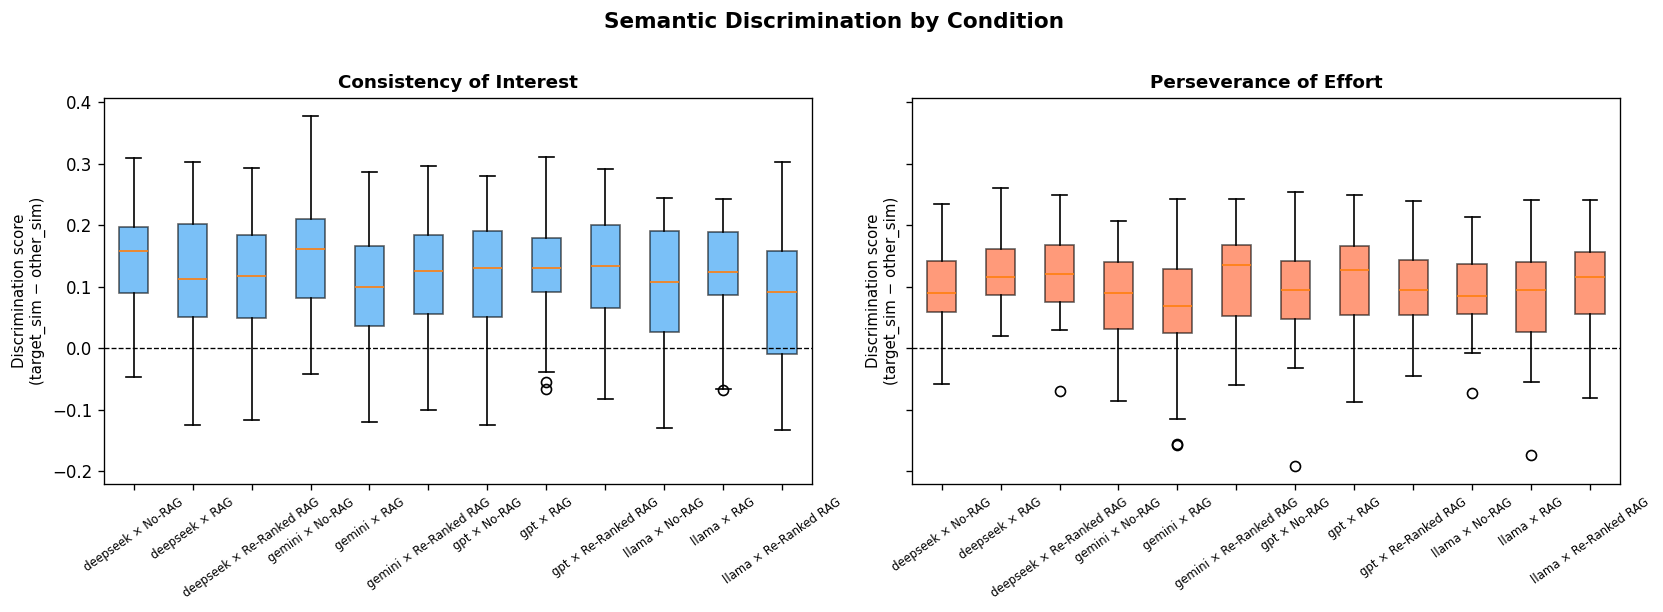


Mean discrimination score by condition and scale:
                                                    mean     std
Condition                Scale                                  
deepseek × No-RAG        Consistency of Interest  0.1434  0.0850
                         Perseverance of Effort   0.0947  0.0754
deepseek × RAG           Consistency of Interest  0.1108  0.1130
                         Perseverance of Effort   0.1247  0.0564
deepseek × Re-Ranked RAG Consistency of Interest  0.1095  0.0918
                         Perseverance of Effort   0.1197  0.0602
gemini × No-RAG          Consistency of Interest  0.1404  0.1007
                         Perseverance of Effort   0.0814  0.0783
gemini × RAG             Consistency of Interest  0.0990  0.0936
                         Perseverance of Effort   0.0684  0.0958
gemini × Re-Ranked RAG   Consistency of Interest  0.1164  0.1017
                         Perseverance of Effort   0.1138  0.0763
gpt × No-RAG             Consistency of

In [17]:
# ── Discrimination score boxplot ─────────────────────────────────────────────
disc_rows = []
for r in records:
    labels = r['_labels']
    disc1  = r['_disc1']
    cond   = r['Condition']
    for lbl, d in zip(labels, disc1):
        disc_rows.append({'Condition': cond, 'Scale': lbl, 'disc_score': d})

disc_df = pd.DataFrame(disc_rows)

conditions_ordered = sorted(disc_df['Condition'].unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, dpi=120)

for ax, scale_name in zip(axes, SCALE_ORDER):
    scale_data = disc_df[disc_df['Scale'] == scale_name]
    plot_data  = [scale_data[scale_data['Condition'] == c]['disc_score'].tolist()
                  for c in conditions_ordered]
    bp = ax.boxplot(plot_data, labels=conditions_ordered, patch_artist=True, notch=False)
    color = SCALE_COLORS[scale_name]
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(scale_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Discrimination score\n(target_sim − other_sim)', fontsize=9)
    ax.tick_params(axis='x', labelrotation=35, labelsize=7)

plt.suptitle('Semantic Discrimination by Condition', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('efa_discrimination_scores.jpeg', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-condition mean discrimination ─────────────────────────────────────────
print("\nMean discrimination score by condition and scale:")
print(disc_df.groupby(['Condition', 'Scale'])['disc_score']
      .agg(['mean', 'std']).round(4).to_string())


*Observations:*

---
## 8.5 — Final Item Bank: Remove Weak & Cross-Loading Items

Items flagged as **cross-loading** (|loading| ≥ 0.30 on both factors) or **weak**
(max |loading| < 0.30) are excluded from further analysis.
What remains is the candidate bank submitted for human review.
The summary table compares pool quality before and after filtering across all conditions.

In [22]:
from IPython.display import display
import pandas as pd
import numpy as np
import pathlib
pathlib.Path('outputs').mkdir(exist_ok=True)

# ── Build filtered item bank ──────────────────────────────────────────────────
bank_rows   = []
bank_items  = []

for r in records:
    cond     = r['Condition']
    sub      = cond_data[cond]['sub'].copy().reset_index(drop=True)
    labels   = r['_labels']
    loadings = r['_loadings']
    cross    = r['_cross']
    weak     = r['_weak']
    disc1    = r['_disc1']
    ci_fac   = r['_ci_fac']
    pe_fac   = r['_pe_fac']
    keep     = ~cross & ~weak

    abs_load     = np.abs(loadings)
    ci_mask_all  = labels == 'Consistency of Interest'
    pe_mask_all  = labels == 'Perseverance of Effort'
    ci_daal_mean = np.mean(abs_load[ci_mask_all, ci_fac]) + 1e-9
    pe_daal_mean = np.mean(abs_load[pe_mask_all, pe_fac]) + 1e-9
    daal_all     = np.where(
        abs_load[:, ci_fac] / ci_daal_mean >= abs_load[:, pe_fac] / pe_daal_mean,
        'Consistency of Interest', 'Perseverance of Effort'
    )
    pct_daal_clean = float((daal_all[keep] == labels[keep]).mean() * 100) if keep.sum() > 0 else np.nan
    mean_cos       = sub.loc[keep, 'cosine_sim'].mean() if 'cosine_sim' in sub.columns else np.nan
    model_name, rag_type = cond.split(' × ', 1)

    bank_rows.append(dict(
        Condition         = cond,
        Model             = model_name,
        RAG_type          = rag_type,
        n_start           = int(len(sub)),
        n_cross_removed   = int(cross.sum()),
        n_weak_removed    = int(weak.sum()),
        n_final           = int(keep.sum()),
        pct_retained      = round(keep.mean() * 100, 1),
        DAAL_acc_before   = r['pct_correct_DAAL'],
        DAAL_acc_after    = round(pct_daal_clean, 1),
        mean_disc_before  = r['mean_disc'],
        mean_disc_after   = round(float(disc1[keep].mean()), 4) if keep.sum() > 0 else np.nan,
        mean_cosine_sim   = round(mean_cos, 4) if not np.isnan(mean_cos) else np.nan,
        residual_rmse     = r['residual_rmse'],
    ))

    for idx in np.where(keep)[0]:
        row = sub.iloc[idx]
        bank_items.append(dict(
            Condition  = cond,
            Model      = model_name,
            RAG_type   = rag_type,
            Scale      = row['Scale'],
            Item_Text  = row['Item_Text'],
            disc_score = round(float(disc1[idx]), 4),
            loading_CI = round(float(loadings[idx, ci_fac]), 3),
            loading_PE = round(float(loadings[idx, pe_fac]), 3),
            cosine_sim = round(float(row['cosine_sim']), 4) if 'cosine_sim' in sub.columns else np.nan,
        ))

bank_summary = pd.DataFrame(bank_rows)
bank_df      = pd.DataFrame(bank_items)

# ── Summary stats table (colour-coded) ───────────────────────────────────────
print("=" * 80)
print("  FINAL ITEM BANK — QUALITY SUMMARY  (all conditions)")
print("=" * 80)
display(
    bank_summary.drop(columns=['Condition'])
    .style
    .set_caption("Item Bank: Before vs After Filtering")
    .format({
        'pct_retained':    '{:.1f}%',
        'DAAL_acc_before': '{:.1f}%',
        'DAAL_acc_after':  '{:.1f}%',
        'mean_disc_before':'{:.4f}',
        'mean_disc_after': '{:.4f}',
        'mean_cosine_sim': '{:.4f}',
        'residual_rmse':   '{:.4f}',
    })
    .background_gradient(subset=['DAAL_acc_after'],  cmap='Greens', vmin=70, vmax=100)
    .background_gradient(subset=['pct_retained'],    cmap='Blues',  vmin=50, vmax=100)
    .background_gradient(subset=['residual_rmse'],   cmap='Reds_r', vmin=0.05, vmax=0.25)
)

# ── Save CSVs ─────────────────────────────────────────────────────────────────
bank_df.to_csv('outputs/final_item_bank.csv', index=False)
bank_summary.to_csv('outputs/final_bank_summary.csv', index=False)
print(f"\n✓ Saved: outputs/final_item_bank.csv  ({len(bank_df)} items)")
print(f"✓ Saved: outputs/final_bank_summary.csv")

  FINAL ITEM BANK — QUALITY SUMMARY  (all conditions)


,Model,RAG_type,n_start,n_cross_removed,n_weak_removed,n_final,pct_retained,DAAL_acc_before,DAAL_acc_after,mean_disc_before,mean_disc_after,mean_cosine_sim,residual_rmse
0,deepseek,No-RAG,80,6,0,74,92.5%,97.5%,98.6%,0.1191,0.1203,0.4597,0.2162
1,deepseek,RAG,79,13,0,66,83.5%,89.9%,97.0%,0.1178,0.1291,0.4748,0.2156
2,deepseek,Re-Ranked RAG,80,8,0,72,90.0%,93.8%,94.4%,0.1146,0.1214,0.4548,0.1922
3,gemini,No-RAG,80,2,0,78,97.5%,50.0%,48.7%,0.1109,0.1097,0.4633,0.2220
4,gemini,RAG,80,5,0,75,93.8%,52.5%,50.7%,0.0837,0.0789,0.4446,0.2234
5,gemini,Re-Ranked RAG,80,6,0,74,92.5%,86.2%,85.1%,0.1151,0.1201,0.4694,0.1983
6,gpt,No-RAG,80,10,0,70,87.5%,90.0%,92.9%,0.1065,0.1095,0.4339,0.1975
7,gpt,RAG,80,17,0,63,78.8%,83.8%,92.1%,0.1144,0.1224,0.4728,0.2084
8,gpt,Re-Ranked RAG,80,7,0,73,91.2%,55.0%,54.8%,0.1126,0.1127,0.4670,0.2292
9,llama,No-RAG,77,9,0,68,88.3%,76.6%,79.4%,0.0956,0.1035,0.4472,0.1912



✓ Saved: outputs/final_item_bank.csv  (846 items)
✓ Saved: outputs/final_bank_summary.csv


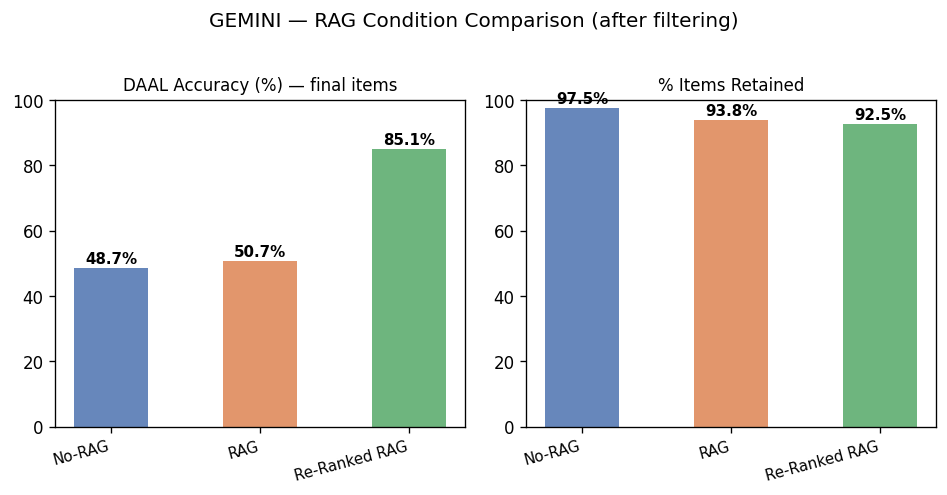

  Saved: outputs/chart_gemini_rag_comparison.jpeg


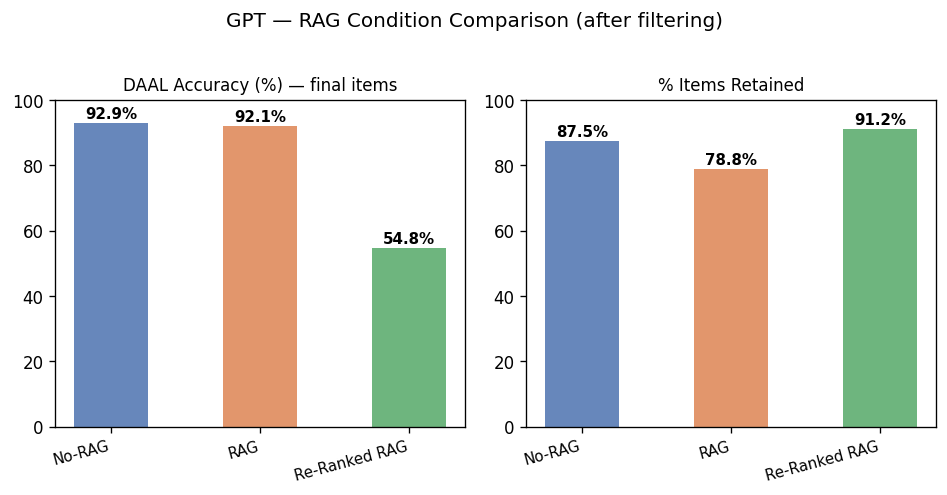

  Saved: outputs/chart_gpt_rag_comparison.jpeg


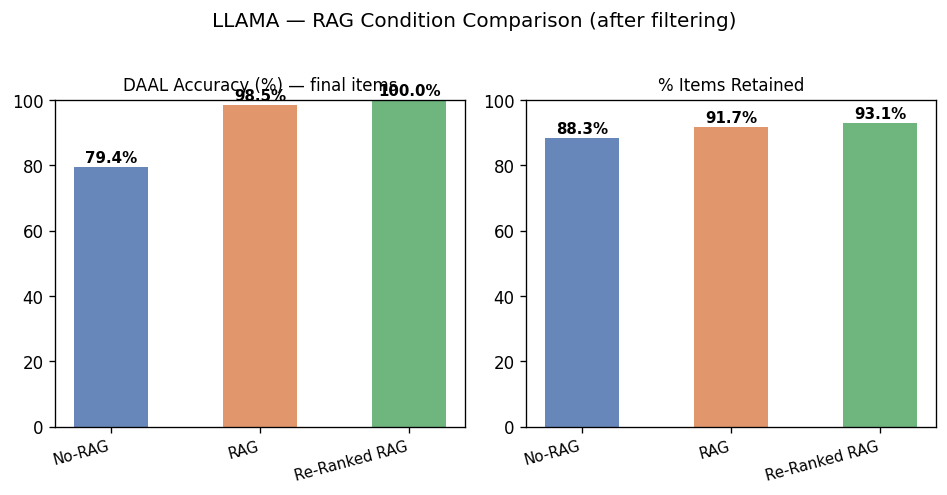

  Saved: outputs/chart_llama_rag_comparison.jpeg


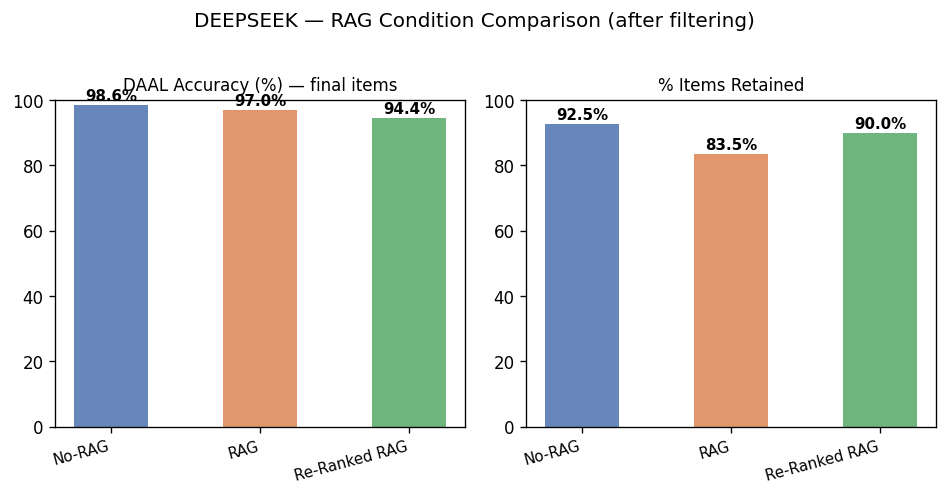

  Saved: outputs/chart_deepseek_rag_comparison.jpeg


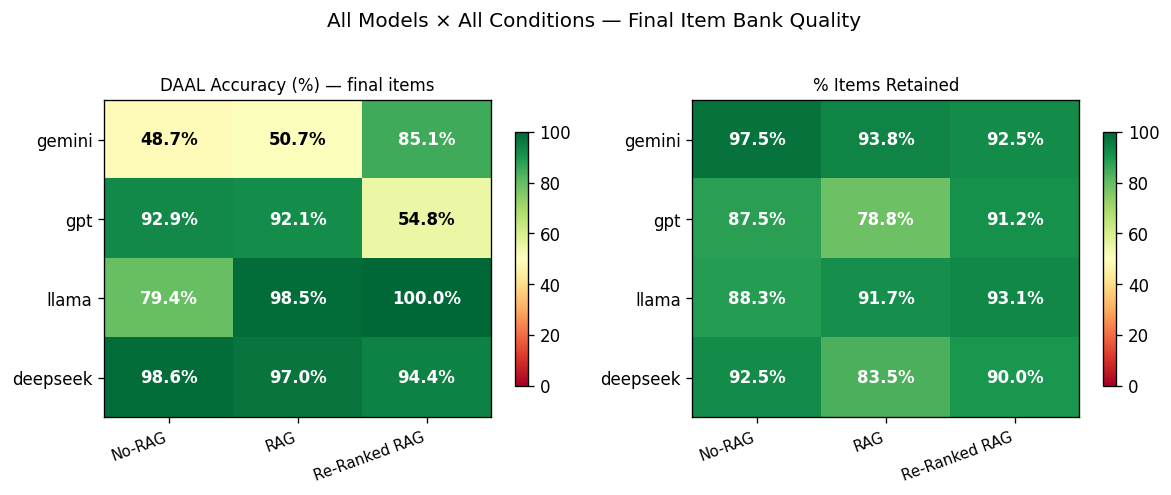

  Saved: outputs/chart_overall_heatmap.jpeg

✓ All charts saved to outputs/  (SHOW_PLOTS=True)


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ── Toggle: set False to skip inline display (charts still saved to disk) ─────
SHOW_PLOTS = True

MODELS    = ['gemini', 'gpt', 'llama', 'deepseek']
RAG_CONDS = ['No-RAG', 'RAG', 'Re-Ranked RAG']
RAG_COLORS = {'No-RAG': '#4c72b0', 'RAG': '#dd8452', 'Re-Ranked RAG': '#55a868'}

metrics = [
    ('DAAL_acc_after', 'DAAL Accuracy (%) — final items', 0, 100),
    ('pct_retained',   '% Items Retained',                0, 100),
]

def get_val(df, model, rag, metric):
    row = df[(df['Model'] == model) & (df['RAG_type'] == rag)]
    return row[metric].values[0] if len(row) else np.nan

# ── Charts 1–4: per model ─────────────────────────────────────────────────────
for model in MODELS:
    fig, axes = plt.subplots(1, len(metrics), figsize=(8, 4), dpi=120)
    fig.suptitle(f'{model.upper()} — RAG Condition Comparison (after filtering)',
                 fontsize=12, y=1.02)

    for ax, (metric, ylabel, ymin, ymax) in zip(axes, metrics):
        vals = [get_val(bank_summary, model, rag, metric) for rag in RAG_CONDS]
        bars = ax.bar(RAG_CONDS, vals,
                      color=[RAG_COLORS[r] for r in RAG_CONDS],
                      alpha=0.85, width=0.5)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.5,
                        f'{v:.1f}%', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')
        ax.set_title(ylabel, fontsize=10)
        ax.set_ylim(ymin, ymax)
        ax.set_xticklabels(RAG_CONDS, rotation=15, ha='right', fontsize=9)

    plt.tight_layout()
    path = f'outputs/chart_{model}_rag_comparison.jpeg'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()
    print(f'  Saved: {path}')

# ── Chart 5: overall heatmap — all models × all conditions ───────────────────
fig, axes = plt.subplots(1, len(metrics), figsize=(10, 4), dpi=120)
fig.suptitle('All Models × All Conditions — Final Item Bank Quality',
             fontsize=12, y=1.02)

for ax, (metric, title, vmin, vmax) in zip(axes, metrics):
    matrix = np.array([[get_val(bank_summary, m, r, metric)
                        for r in RAG_CONDS] for m in MODELS])
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')

    for i in range(len(MODELS)):
        for j in range(len(RAG_CONDS)):
            v = matrix[i, j]
            if not np.isnan(v):
                brightness = (v - vmin) / max(vmax - vmin, 1e-9)
                color = 'white' if brightness < 0.35 or brightness > 0.75 else 'black'
                ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

    ax.set_xticks(range(len(RAG_CONDS)))
    ax.set_yticks(range(len(MODELS)))
    ax.set_xticklabels(RAG_CONDS, rotation=20, ha='right', fontsize=9)
    ax.set_yticklabels(MODELS, fontsize=10)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
path = 'outputs/chart_overall_heatmap.jpeg'
plt.savefig(path, dpi=150, bbox_inches='tight')
if SHOW_PLOTS:
    plt.show()
else:
    plt.close()
print(f'  Saved: {path}')
print(f'\n✓ All charts saved to outputs/  (SHOW_PLOTS={SHOW_PLOTS})')

---
# Phase 9 — AI-GENIE Validation
Applies the AI-GENIE psychometric pipeline (Russell-Lasalandra, Christensen & Golino, 2025) to validate
generated items independently for each of the 12 conditions (4 models × 3 generation methods).

**Pipeline per condition:**
1. **EGA** (TMFG + glasso) — identify network communities, compute NMI/ARI vs known CI/PE structure
2. **UVA** (wTO ≤ 0.20, iterative) — remove redundant items
3. **Sparse check** — compare full vs sparsified embeddings; use whichever yields higher NMI
4. **bootEGA** (100 iterations, stability ≥ 0.75, iterative) — remove unstable items
5. **Final EGA** — compute final NMI/ARI on the stable item pool

**R packages:** EGAnet, igraph  
**Python report:** merges R results with item text, flags theory mismatches

## 9.1 — Save Per-Condition Embeddings to Disk
Export one `embeddings.csv` (1536 rows × N_items cols) and one `item_labels.csv` per condition
from `master_df` (computed in Phase 7). These are the inputs for the R pipeline.

In [29]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

assert 'embedding' in master_df.columns, "Run Phase 7 first to populate master_df['embedding']"

VALIDATION_DIR = Path('validation')
OUTPUTS_DIR    = VALIDATION_DIR / 'outputs'

# Condition key → safe folder name
def safe_name(s):
    return (s.replace(' × ', '_')
             .replace('-', '_')
             .replace(' ', '_')
             .replace('__', '_'))

# Scale → community id (1 = CI, 2 = PE)
COMMUNITY_MAP = {
    'Consistency of Interest': 1,
    'Perseverance of Effort':  2,
}

conditions = sorted(master_df['Condition_Key'].unique())
print(f"Saving embeddings for {len(conditions)} conditions …")

for cond_key in conditions:
    folder = OUTPUTS_DIR / safe_name(cond_key)
    folder.mkdir(parents=True, exist_ok=True)

    sub = master_df[master_df['Condition_Key'] == cond_key].reset_index(drop=True)
    n   = len(sub)

    # ── embeddings.csv: 1536 rows × n cols (as required by AI-GENIE paper) ──
    emb_matrix = np.vstack(sub['embedding'].values).T.astype(np.float64)  # (1536, n)
    item_names = [f"item_{i}" for i in range(n)]
    dim_names  = [f"dim_{d}" for d in range(emb_matrix.shape[0])]

    emb_df = pd.DataFrame(emb_matrix, index=dim_names, columns=item_names)
    emb_df.to_csv(folder / 'embeddings.csv')

    # ── item_labels.csv: item_index, item_text, original_dimension, community_id
    labels_df = pd.DataFrame({
        'item_index':          item_names,
        'item_text':           sub['Item_Text'].values,
        'original_dimension':  sub['Scale'].values,
        'community_id':        sub['Scale'].map(COMMUNITY_MAP).values,
    })
    labels_df.to_csv(folder / 'item_labels.csv', index=False)

    print(f"  {cond_key:30s}  n={n}  → {folder}")

print("\nDone.")


Saving embeddings for 12 conditions …
  deepseek × No-RAG               n=80  → validation/outputs/deepseek_No_RAG
  deepseek × RAG                  n=79  → validation/outputs/deepseek_RAG


  deepseek × Re-Ranked RAG        n=80  → validation/outputs/deepseek_Re_Ranked_RAG


  gemini × No-RAG                 n=80  → validation/outputs/gemini_No_RAG
  gemini × RAG                    n=80  → validation/outputs/gemini_RAG


  gemini × Re-Ranked RAG          n=80  → validation/outputs/gemini_Re_Ranked_RAG


  gpt × No-RAG                    n=80  → validation/outputs/gpt_No_RAG
  gpt × RAG                       n=80  → validation/outputs/gpt_RAG
  gpt × Re-Ranked RAG             n=80  → validation/outputs/gpt_Re_Ranked_RAG


  llama × No-RAG                  n=77  → validation/outputs/llama_No_RAG


  llama × RAG                     n=72  → validation/outputs/llama_RAG
  llama × Re-Ranked RAG           n=72  → validation/outputs/llama_Re_Ranked_RAG

Done.


## 9.2 — Run EGA Pipeline (R) + Report (Python) for All Conditions
Calls `validation/ega_pipeline.R` then `validation/step6_report.py` for each condition via subprocess.
**Note:** bootEGA runs 100 bootstrap iterations per sweep — expect ~3–6 minutes per condition (~1 hour total).

In [30]:
import subprocess, sys, time
from pathlib import Path

VALIDATION_DIR = Path('validation')
R_SCRIPT       = VALIDATION_DIR / 'ega_pipeline.R'
PY_REPORT      = VALIDATION_DIR / 'step6_report.py'
OUTPUTS_DIR    = VALIDATION_DIR / 'outputs'

def safe_name(s):
    return (s.replace(' × ', '_')
             .replace('-', '_')
             .replace(' ', '_')
             .replace('__', '_'))

conditions = sorted(master_df['Condition_Key'].unique())

run_log = []   # collect (condition, returncode, duration, stdout_tail)

for cond_key in conditions:
    folder = OUTPUTS_DIR / safe_name(cond_key)
    print(f"\n{'='*60}")
    print(f"Condition: {cond_key}")
    print('='*60)

    t0 = time.time()

    # ── R pipeline (Steps 2–5) ────────────────────────────────────────────────
    r_result = subprocess.run(
        ['Rscript', str(R_SCRIPT), str(folder)],
        capture_output=False,   # stream to notebook output
        text=True
    )
    r_elapsed = time.time() - t0

    if r_result.returncode != 0:
        print(f"  ✗ R pipeline failed (rc={r_result.returncode}) — skipping report.")
        run_log.append(dict(Condition=cond_key, R_ok=False, Py_ok=False,
                            elapsed_s=round(r_elapsed)))
        continue

    # ── Python report (Step 6) ────────────────────────────────────────────────
    py_result = subprocess.run(
        [sys.executable, str(PY_REPORT), str(folder)],
        capture_output=False,
        text=True
    )
    elapsed = time.time() - t0

    ok = py_result.returncode == 0
    run_log.append(dict(Condition=cond_key, R_ok=True, Py_ok=ok,
                        elapsed_s=round(elapsed)))
    print(f"  {'✓' if ok else '✗'} Finished in {elapsed:.0f}s")

print("\n── Run log ──")
log_df = pd.DataFrame(run_log)
print(log_df.to_string(index=False))



Condition: deepseek × No-RAG


Warning messages:
1: package ‘EGAnet’ was built under R version 4.5.2 
2: package ‘igraph’ was built under R version 4.5.2 


EGAnet: 2.4.0  | igraph: 2.2.2 
Items: 80 | Dims: 1536 
Dimensions: Consistency of Interest, Perseverance of Effort 

── Step 2: Initial EGA ──


  TMFG:   NMI=36.5%  ARI=30.1%
  glasso: NMI=43.3%  ARI=30.8%
  Best initial model: glasso 

── Step 3: Iterative UVA ──


  Sweep 1: removed 4 → 76 remaining


...

  Sweep 1: removed 15 → 57 remaining
  No reduced data returned — UVA converged (no more redundancies).
  UVA done: 15 removed in 2 sweep(s) → 57 remaining

── Step 4: Sparse vs Full ──
  Full NMI: 37.9%   Sparse NMI: 46.0%
  Using: sparse 

── Step 5: Iterative bootEGA ──


  Sweep 1: stable=23  unstable=34
    Removed: item_0, item_2, item_5, item_7, item_8, item_9, item_10, item_14, item_16, item_17, item_19, item_20, item_22, item_25, item_26, item_27, item_28, item_29, item_32, item_33, item_34, item_35, item_36, item_38, item_44, item_45, item_47, item_51, item_52, item_53, item_56, item_57, item_58, item_71 
    Remaining: 23 


  Sweep 2: stable=23  unstable=0

── Step 6: Final EGA ──
  Final NMI: 69.2%  ARI: 46.9%
  Items: 72 → 23

✓ Saved to validation/outputs/llama_Re_Ranked_RAG
  Initial NMI: 52.4% → Final NMI: 69.2%

  Initial NMI: 52.4%  ARI: 38.0%
  Final   NMI: 69.2%  ARI: 46.9%
  NMI improvement: +16.8%
  Items: 72 start → 57 after UVA → 23 final
  Match theory: 23/23 (100.0%)
  Per dimension: {'Consistency of Interest': 6, 'Perseverance of Effort': 17}
  Embedding: sparse  Model: glasso
  Saved: final_item_pool.csv (23 items), final_report.json


There were 20 warnings (use warnings() to see them)


  ✓ Finished in 5s

── Run log ──
               Condition  R_ok  Py_ok  elapsed_s
       deepseek × No-RAG  True   True          7
          deepseek × RAG  True   True         10
deepseek × Re-Ranked RAG  True   True          7
         gemini × No-RAG  True   True          7
            gemini × RAG  True   True          8
  gemini × Re-Ranked RAG  True   True          9
            gpt × No-RAG  True   True          9
               gpt × RAG  True   True          9
     gpt × Re-Ranked RAG  True   True          8
          llama × No-RAG  True   True          6
             llama × RAG  True   True          7
   llama × Re-Ranked RAG  True   True          5


## 9.3 — Aggregate Results Across All Conditions

,Condition,items_start,items_after_uva,items_after_boot,items_removed,initial_nmi_pct,final_nmi_pct,nmi_improvement,initial_ari_pct,final_ari_pct,pct_match,embedding_type,best_model_initial,items_per_dim
0,llama × No-RAG,77,68,22,55,35.6,74.8,39.2,21.1,58.1,100.0,full,glasso,Con: 14 | Per: 8
1,gpt × No-RAG,80,72,24,56,34.2,71.1,36.9,21.5,50.4,100.0,sparse,TMFG,Con: 17 | Per: 7
2,llama × Re-Ranked RAG,72,57,23,49,52.4,69.2,16.8,38.0,46.9,100.0,sparse,glasso,Con: 6 | Per: 17
3,gpt × RAG,80,77,40,40,54.1,67.7,13.7,40.0,51.9,100.0,sparse,glasso,Con: 18 | Per: 22
4,deepseek × RAG,79,69,28,51,33.0,67.3,34.4,18.8,49.4,100.0,full,TMFG,Con: 15 | Per: 13
5,gemini × No-RAG,80,67,29,51,30.7,67.1,36.4,26.4,48.8,100.0,sparse,glasso,Con: 15 | Per: 14
6,llama × RAG,72,64,36,36,58.0,67.1,9.1,47.2,49.2,100.0,full,glasso,Con: 17 | Per: 19
7,deepseek × No-RAG,80,76,41,39,43.3,59.9,16.6,30.8,47.9,97.6,full,glasso,Con: 24 | Per: 17
8,gpt × Re-Ranked RAG,80,69,43,37,51.8,52.2,0.4,35.9,40.3,95.3,full,glasso,Con: 21 | Per: 22
9,deepseek × Re-Ranked RAG,80,70,25,55,38.2,51.6,13.4,26.2,32.4,96.0,full,glasso,Con: 18 | Per: 7


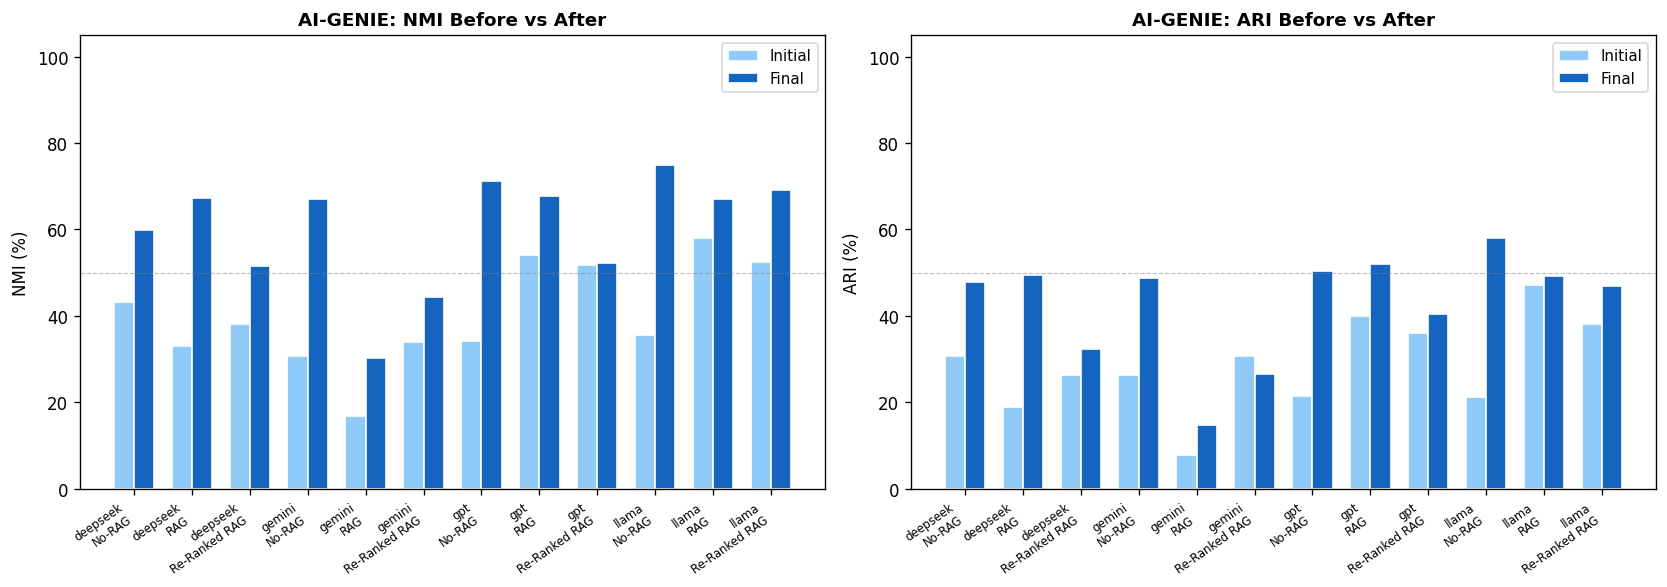

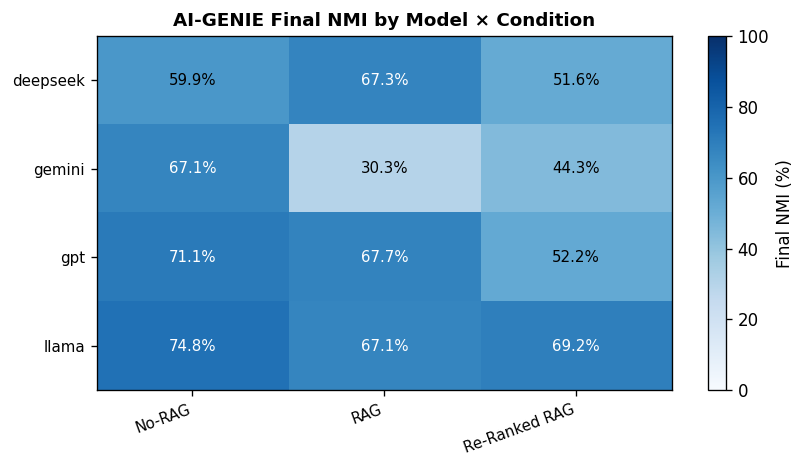


── Stable items per dimension ──
  deepseek × No-RAG                    Con: 24  |  Per: 17
  deepseek × RAG                       Con: 15  |  Per: 13
  deepseek × Re-Ranked RAG             Con: 18  |  Per: 7
  gemini × No-RAG                      Con: 15  |  Per: 14
  gemini × RAG                         Con: 19  |  Per: 8
  gemini × Re-Ranked RAG               Con: 20  |  Per: 9
  gpt × No-RAG                         Con: 17  |  Per: 7
  gpt × RAG                            Con: 18  |  Per: 22
  gpt × Re-Ranked RAG                  Con: 21  |  Per: 22
  llama × No-RAG                       Con: 14  |  Per: 8
  llama × RAG                          Con: 17  |  Per: 19
  llama × Re-Ranked RAG                Con: 6  |  Per: 17


In [25]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ── Load JSON reports ─────────────────────────────────────────────────────────
OUTPUTS_DIR = Path('outputs/validation/outputs')   # actual folder on disk

def safe_name(s):
    return s.replace(' × ', '_').replace('-', '_').replace(' ', '_').replace('__', '_')

conditions = sorted(master_df['Condition_Key'].unique())

agg_rows = []
for cond_key in conditions:
    folder      = OUTPUTS_DIR / safe_name(cond_key)
    report_path = folder / 'final_report.json'
    if not report_path.exists():
        print(f"  Missing: {report_path}")
        continue
    with open(report_path) as f:
        rep = json.load(f)
    rep['Condition'] = cond_key
    rep['model']     = cond_key.split(' × ')[0]
    rep['method']    = cond_key.split(' × ')[1]
    # Flatten items_per_dimension dict into readable string
    ipd = rep.pop('items_per_dimension', {})
    rep['items_per_dim'] = '  |  '.join(f"{k[:3]}: {v}" for k, v in ipd.items())
    agg_rows.append(rep)

if not agg_rows:
    print("No reports found — run Phase 9.2 first.")
else:
    agg_df = pd.DataFrame(agg_rows)

    # ── Summary table ─────────────────────────────────────────────────────────
    show_cols = ['Condition', 'items_start', 'items_after_uva', 'items_after_boot',
                 'items_removed', 'initial_nmi_pct', 'final_nmi_pct', 'nmi_improvement',
                 'initial_ari_pct', 'final_ari_pct', 'pct_match',
                 'embedding_type', 'best_model_initial', 'items_per_dim']
    present = [c for c in show_cols if c in agg_df.columns]

    display(
        agg_df[present]
        .sort_values('final_nmi_pct', ascending=False)
        .reset_index(drop=True)
        .style
        .set_caption("AI-GENIE Results — All Conditions")
        .format({c: '{:.1f}' for c in ['initial_nmi_pct','final_nmi_pct','nmi_improvement',
                                        'initial_ari_pct','final_ari_pct','pct_match']
                 if c in present})
        .background_gradient(subset=[c for c in ['final_nmi_pct','final_ari_pct'] if c in present],
                             cmap='Greens', vmin=0, vmax=100)
    )

    # ── Bar chart: NMI & ARI before/after ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
    for ax, (pre_col, post_col), label in zip(
        axes,
        [('initial_nmi_pct', 'final_nmi_pct'), ('initial_ari_pct', 'final_ari_pct')],
        ['NMI', 'ARI']
    ):
        if pre_col not in agg_df.columns:
            ax.set_visible(False); continue
        x, w = range(len(agg_df)), 0.35
        ax.bar([i - w/2 for i in x], agg_df[pre_col],  width=w, label='Initial',
               color='#90CAF9', edgecolor='white')
        ax.bar([i + w/2 for i in x], agg_df[post_col], width=w, label='Final',
               color='#1565C0', edgecolor='white')
        ax.set_xticks(list(x))
        ax.set_xticklabels([c.replace(' × ', '\n') for c in agg_df['Condition']],
                           rotation=35, ha='right', fontsize=7)
        ax.set_ylabel(f'{label} (%)', fontsize=10)
        ax.set_title(f'AI-GENIE: {label} Before vs After', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.axhline(50, color='grey', ls='--', lw=0.7, alpha=0.5)
        ax.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig('aigenie_nmi_ari_comparison.jpeg', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Heatmap: final NMI by model × method ─────────────────────────────────
    pivot = agg_df.pivot(index='model', columns='method', values='final_nmi_pct')
    fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=120)
    im = ax2.imshow(pivot.values.astype(float), cmap='Blues', vmin=0, vmax=100, aspect='auto')
    ax2.set_xticks(range(len(pivot.columns)))
    ax2.set_yticks(range(len(pivot.index)))
    ax2.set_xticklabels(pivot.columns, rotation=20, ha='right', fontsize=9)
    ax2.set_yticklabels(pivot.index, fontsize=9)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            txt = f'{float(val):.1f}%' if pd.notna(val) else 'n/a'
            color = 'white' if pd.notna(val) and float(val) > 60 else 'black'
            ax2.text(j, i, txt, ha='center', va='center', fontsize=9, color=color)
    plt.colorbar(im, ax=ax2, label='Final NMI (%)')
    ax2.set_title('AI-GENIE Final NMI by Model × Condition', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('aigenie_nmi_heatmap.jpeg', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Per-dimension stable item counts ─────────────────────────────────────
    print("\n── Stable items per dimension ──")
    for _, row in agg_df.sort_values('Condition').iterrows():
        print(f"  {row['Condition']:35s}  {row.get('items_per_dim', '')}")

# Phase 10 — Results: Validation Summary and Final Item Pool


> **Key findings at a glance**
> - **940 items evaluated** across 12 conditions (4 models × 3 retrieval strategies)
> - **Best overall — EFA-based validation:** DeepSeek — DAAL 94–99%, highest mean disc scores (0.121–0.129)
> - **Best overall — AI-GENIE validation:** Llama × No-RAG — NMI final 74.8%, 100% community-to-theory match
> - **Worst conditions:** Gemini × RAG (DAAL 50.7%, disc 0.079, NMI 30.3%) and GPT × Re-Ranked RAG (NMI Δ = +0.4%) — excluded from human review
> - **Method agreement:** Both methods agreed in 7 of 12 conditions; 5 conditions showed informative partial disagreement
> - **Final item pool: 89 items** (50 CI · 39 PE) from the three highest-quality conditions after discrimination filtering and cross-condition deduplication



**Phase 8 — EFA-based validation** applies pseudo-factor analysis to sentence embeddings (MiniLM-L12-v2, 384 dimensions). Two factors are extracted using principal axis factoring with Oblimin rotation and each item is assigned to its intended factor. The key metric is **DAAL accuracy** — percentage of items correctly assigned by factor loading pattern. Items are also scored on a **discrimination score** (disc_score) measuring how selectively each item loads on its intended subscale.

**Phase 9 — AI-GENIE validation** applies the AI-GENIE network psychometrics pipeline (Russell-Lasalandra et al., 2025) to the same embeddings. EGA with TMFG/glasso detects item communities; UVA removes redundant items (wTO > 0.20); bootEGA (100 iterations) removes unstable items (stability < 0.75). The key metric is **NMI final** — how well detected communities match the theoretical subscale structure. Both methods run independently on the same item pools; Table 1 below consolidates all results.


## 10.0 — Load & Merge Results

Consolidates EFA (Phase 8) and AI-GENIE/EGA (Phase 9) results into a single comparative dashboard. All outputs are saved to `outputs/`.

> **Prerequisites:** run Phases 8–9 first so that `outputs/final_bank_summary.csv`, `outputs/final_item_bank.csv`, and `outputs/validation/outputs/*/final_report.json` exist.

In [26]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")

# ── EFA outputs ────────────────────────────────────────────────────────────────
efa  = pd.read_csv("outputs/final_bank_summary.csv")
bank = pd.read_csv("outputs/final_item_bank.csv")

# ── EGA reports ────────────────────────────────────────────────────────────────
_rag_decode = {"No_RAG": "No-RAG", "RAG": "RAG", "Re_Ranked_RAG": "Re-Ranked RAG"}

def _folder_to_cond(folder):
    model, *rest = folder.split("_", 1)
    rag_raw = rest[0] if rest else ""
    rag = _rag_decode.get(rag_raw, rag_raw.replace("_", " "))
    return f"{model} × {rag}"

ega_rows = []
for fld in sorted(Path("outputs/validation/outputs").iterdir()):
    rpt = fld / "final_report.json"
    if fld.is_dir() and rpt.exists():
        data = json.loads(rpt.read_text())
        data["Condition"] = _folder_to_cond(fld.name)
        ega_rows.append(data)
ega = pd.DataFrame(ega_rows)

# ── Negative-disc count per condition (from final item bank) ───────────────────
neg_disc = (bank[bank["disc_score"] < 0]
            .groupby("Condition").size()
            .rename("n_neg_disc"))

# ── Merge all ─────────────────────────────────────────────────────────────────
m = efa.merge(ega, on="Condition", how="left")
m = m.merge(neg_disc, on="Condition", how="left")
m["n_neg_disc"] = m["n_neg_disc"].fillna(0).astype(int)

print(f"Loaded {len(m)} conditions.")
display(m[["Condition", "DAAL_acc_after", "mean_disc_after",
           "n_neg_disc", "final_nmi_pct", "pct_match"]].round(1))


Loaded 12 conditions.


,Condition,DAAL_acc_after,mean_disc_after,n_neg_disc,final_nmi_pct,pct_match
0,deepseek × No-RAG,98.6,0.1,5,59.9,97.6
1,deepseek × RAG,97.0,0.1,4,67.3,100.0
2,deepseek × Re-Ranked RAG,94.4,0.1,4,51.6,96.0
3,gemini × No-RAG,48.7,0.1,12,67.1,100.0
4,gemini × RAG,50.7,0.1,14,30.3,85.2
5,gemini × Re-Ranked RAG,85.1,0.1,7,44.3,89.7
6,gpt × No-RAG,92.9,0.1,7,71.1,100.0
7,gpt × RAG,92.1,0.1,7,67.7,100.0
8,gpt × Re-Ranked RAG,54.8,0.1,9,52.2,95.3
9,llama × No-RAG,79.4,0.1,6,74.8,100.0


## Master Validation Results

All 12 conditions × all key metrics, sorted by EGA final NMI descending.

In [ ]:
t1 = (m[[
    "Model", "RAG_type", "items_start", "n_final",
    "DAAL_acc_after", "mean_disc_after", "n_neg_disc",
    "initial_nmi_pct", "final_nmi_pct", "nmi_improvement",
    "pct_match", "items_after_boot", "residual_rmse"
]]
.rename(columns={
    "RAG_type":        "Condition",
    "items_start":     "n_start (EGA)",
    "n_final":         "n_final (EFA)",
    "DAAL_acc_after":  "DAAL%",
    "mean_disc_after": "mean_disc",
    "initial_nmi_pct": "NMI_init",
    "final_nmi_pct":   "NMI_final",
    "nmi_improvement": "NMI_Δ",
    "pct_match":       "EGA_match%",
    "items_after_boot":"EGA_kept",
    "residual_rmse":   "RMSE",
})
.sort_values("NMI_final", ascending=False)
.reset_index(drop=True)
)

def _hi_daal(v):
    return "background-color:#d4edda" if v >= 80 else (
           "background-color:#ffe0e0" if v < 60 else "")

def _hi_nmi(v):
    return "background-color:#d4edda" if v >= 60 else (
           "background-color:#ffe0e0" if v < 40 else "")

styled = (t1.style
  .format({"DAAL%": "{:.1f}", "mean_disc": "{:.3f}",
           "NMI_init": "{:.1f}", "NMI_final": "{:.1f}", "NMI_Δ": "{:.1f}",
           "EGA_match%": "{:.1f}", "RMSE": "{:.4f}"})
  .map(_hi_daal, subset=["DAAL%"])
  .map(_hi_nmi,  subset=["NMI_final"])
  .set_caption("Table 1 — Master Validation Results (sorted by NMI_final ↓)")
)
display(styled)

# Save CSV
t1.to_csv("outputs/table1_master_results.csv", index=False)
print("Saved → outputs/table1_master_results.csv")


## Method Agreement / Disagreement

EFA verdict: DAAL ≥ 80% = pass. EGA verdict: NMI_final ≥ 60% = pass.

In [29]:
_interp = {
    ("pass","pass"): "Both methods agree — structurally sound",
    ("fail","pass"): "EGA stable communities; EFA loadings diffuse (weak discrimination)",
    ("pass","fail"): "EFA factor structure clear; EGA communities noisy or imbalanced",
    ("fail","fail"): "Both methods flag poor structure — not recommended",
}

t2_rows = []
for _, r in m.iterrows():
    efa_v = "pass" if r["DAAL_acc_after"] >= 80 else "fail"
    ega_v = "pass" if r["final_nmi_pct"]  >= 60 else "fail"
    agree = "Y" if efa_v == ega_v else "N"
    t2_rows.append({
        "Condition":       r["Condition"],
        "EFA_DAAL%":       round(r["DAAL_acc_after"], 1),
        "EFA_verdict":     efa_v,
        "EGA_NMI%":        round(r["final_nmi_pct"],  1),
        "EGA_verdict":     ega_v,
        "Agreement":       agree,
        "Interpretation":  _interp[(efa_v, ega_v)],
    })

t2 = pd.DataFrame(t2_rows).sort_values("EGA_NMI%", ascending=False).reset_index(drop=True)

def _color_verdict(v):
    return "color:#28a745;font-weight:bold" if v=="pass" else "color:#dc3545;font-weight:bold"

def _color_agree(v):
    return "background-color:#d4edda" if v=="Y" else "background-color:#fff3cd"

styled2 = (t2.style
  .map(_color_verdict, subset=["EFA_verdict","EGA_verdict"])
  .map(_color_agree, subset=["Agreement"])
  .set_caption("Table 2 — Method Agreement Summary")
)
display(styled2)

t2.to_csv("outputs/table2_method_agreement.csv", index=False)
print("Saved → outputs/table2_method_agreement.csv")


,Condition,EFA_DAAL%,EFA_verdict,EGA_NMI%,EGA_verdict,Agreement,Interpretation
0,llama × No-RAG,79.400000,fail,74.800000,pass,N,EGA stable communities; EFA loadings diffuse (weak discrimination)
1,gpt × No-RAG,92.900000,pass,71.100000,pass,Y,Both methods agree — structurally sound
2,llama × Re-Ranked RAG,100.000000,pass,69.200000,pass,Y,Both methods agree — structurally sound
3,gpt × RAG,92.100000,pass,67.700000,pass,Y,Both methods agree — structurally sound
4,deepseek × RAG,97.000000,pass,67.300000,pass,Y,Both methods agree — structurally sound
5,gemini × No-RAG,48.700000,fail,67.100000,pass,N,EGA stable communities; EFA loadings diffuse (weak discrimination)
6,llama × RAG,98.500000,pass,67.100000,pass,Y,Both methods agree — structurally sound
7,deepseek × No-RAG,98.600000,pass,59.900000,fail,N,EFA factor structure clear; EGA communities noisy or imbalanced
8,gpt × Re-Ranked RAG,54.800000,fail,52.200000,fail,Y,Both methods flag poor structure — not recommended
9,deepseek × Re-Ranked RAG,94.400000,pass,51.600000,fail,N,EFA factor structure clear; EGA communities noisy or imbalanced


Saved → outputs/table2_method_agreement.csv


---
## Top 10 Items by Discrimination Score

Showcase items across all conditions (disc_score ≥ 0, sorted descending).EGA_match reflects the condition-level pct_match from the AI-GENIE report.

In [31]:
# Attach condition-level EGA match% to bank
ega_match_map = m.set_index("Condition")["pct_match"].to_dict()
bank["EGA_match%"] = bank["Condition"].map(ega_match_map)

top10 = (bank[bank["disc_score"] >= 0]
         .sort_values("disc_score", ascending=False)
         .head(10)
         [["Item_Text","Model","Condition","Scale","disc_score","cosine_sim","EGA_match%"]]
         .reset_index(drop=True))

top10.index += 1   # 1-based rank

styled4 = (top10.style
  .format({"disc_score": "{:.3f}", "cosine_sim": "{:.3f}", "EGA_match%": "{:.1f}"})
  .background_gradient(subset=["disc_score"], cmap="YlGn")
  .set_caption("Table 4 — Top 10 Items by Discrimination Score"))
display(styled4)

top10.to_csv("outputs/table4_top10_items.csv")
print("Saved → outputs/table4_top10_items.csv")


,Item_Text,Model,Condition,Scale,disc_score,cosine_sim,EGA_match%
1,My focus on a single ambition is strong.,gemini,gemini × No-RAG,Consistency of Interest,0.379,0.724,100.0
2,It's challenging for me to focus on a single ambition.,gpt,gpt × RAG,Consistency of Interest,0.311,0.660,100.0
3,I resist the urge to frequently switch my primary focus.,deepseek,deepseek × No-RAG,Consistency of Interest,0.309,0.629,97.6
4,Can focus on a single goal for a long time.,llama,llama × Re-Ranked RAG,Consistency of Interest,0.303,0.748,100.0
5,My focus doesn't get scattered by new ideas.,deepseek,deepseek × RAG,Consistency of Interest,0.303,0.558,100.0
6,"When I am focused on a main aim, I rarely let my attention wander.",deepseek,deepseek × No-RAG,Consistency of Interest,0.297,0.621,97.6
7,My attention shifts rapidly between interests.,gemini,gemini × Re-Ranked RAG,Consistency of Interest,0.297,0.507,89.7
8,Discipline is required to maintain focus on a single objective.,deepseek,deepseek × Re-Ranked RAG,Consistency of Interest,0.293,0.658,96.0
9,I frequently shift my focus to fleeting interests.,gpt,gpt × Re-Ranked RAG,Consistency of Interest,0.291,0.565,95.3
10,I possess the ability to maintain focus on a singular objective.,gemini,gemini × No-RAG,Consistency of Interest,0.285,0.675,100.0


Saved → outputs/table4_top10_items.csv


### EFA DAAL% vs EGA NMI final (scatter)

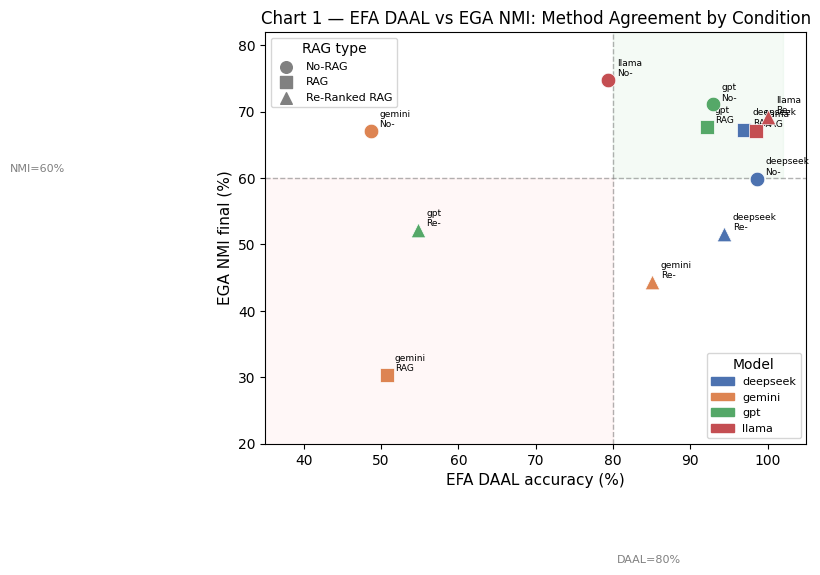

Saved → outputs/chart_c1_daal_vs_nmi.jpeg


In [32]:
MODEL_COLORS = {"deepseek": "#4C72B0", "gemini": "#DD8452",
                "gpt": "#55A868", "llama": "#C44E52"}
RAG_MARKERS  = {"No-RAG": "o", "RAG": "s", "Re-Ranked RAG": "^"}
RAG_LABELS   = {"No-RAG": "No-RAG", "RAG": "RAG", "Re-Ranked RAG": "Re-Ranked RAG"}

fig, ax = plt.subplots(figsize=(9, 6))

# Reference lines
ax.axvline(80, color="gray", lw=1, ls="--", alpha=0.6)
ax.axhline(60, color="gray", lw=1, ls="--", alpha=0.6)
ax.text(80.5, 2, "DAAL=80%", fontsize=8, color="gray")
ax.text(2,  61, "NMI=60%",  fontsize=8, color="gray")

# Quadrant shading
ax.fill_between([80,102],[60,60],[102,102], color="#d4edda", alpha=0.25)   # TL pass
ax.fill_between([0,80],  [0,0],  [60,60],  color="#ffe0e0", alpha=0.25)   # BR fail

for _, r in m.iterrows():
    ax.scatter(r["DAAL_acc_after"], r["final_nmi_pct"],
               color=MODEL_COLORS[r["Model"]],
               marker=RAG_MARKERS[r["RAG_type"]],
               s=110, zorder=4, edgecolors="white", linewidths=0.5)
    ax.annotate(f"{r['Model']}\n{r['RAG_type'][:3]}",
                (r["DAAL_acc_after"], r["final_nmi_pct"]),
                fontsize=6.5, textcoords="offset points", xytext=(6, 3))

# Legend — model color
leg_model = [mpatches.Patch(color=c, label=k) for k, c in MODEL_COLORS.items()]
# Legend — RAG shape
leg_rag = [plt.scatter([],[], marker=v, c="gray", s=70, label=k)
           for k, v in RAG_MARKERS.items()]

l1 = ax.legend(handles=leg_model, title="Model",    loc="lower right", fontsize=8)
ax.add_artist(l1)
ax.legend(handles=leg_rag,   title="RAG type", loc="upper left",  fontsize=8)

ax.set_xlabel("EFA DAAL accuracy (%)", fontsize=11)
ax.set_ylabel("EGA NMI final (%)", fontsize=11)
ax.set_title("Chart 1 — EFA DAAL vs EGA NMI: Method Agreement by Condition", fontsize=12)
ax.set_xlim(35, 105); ax.set_ylim(20, 82)

plt.tight_layout()
plt.savefig("outputs/chart_c1_daal_vs_nmi.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/chart_c1_daal_vs_nmi.jpeg")


### Disc Score Distribution by Model

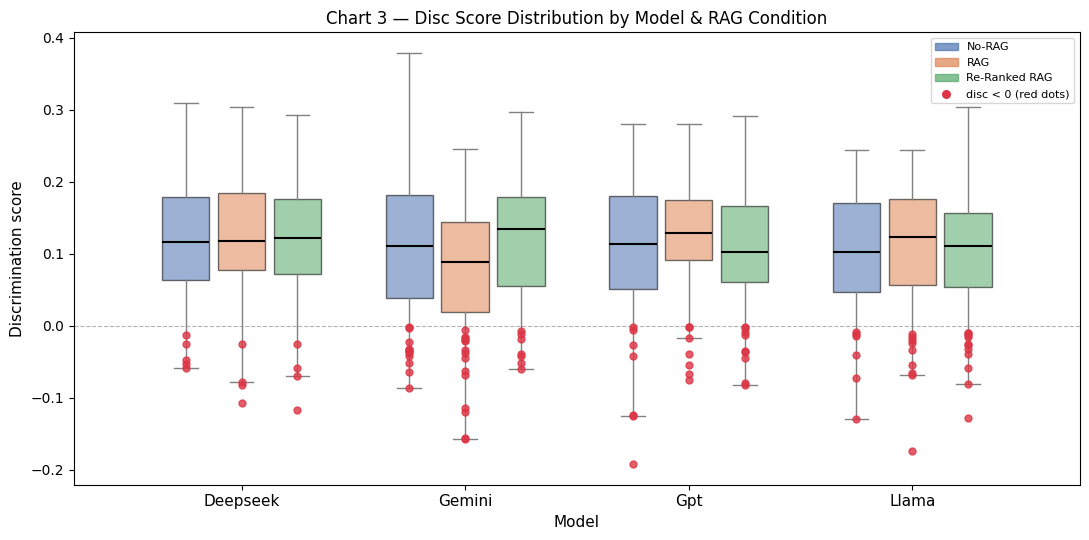

Saved → outputs/chart_c3_disc_boxplot.jpeg


In [33]:
models   = ["deepseek", "gemini", "gpt", "llama"]
rag_conds = ["No-RAG", "RAG", "Re-Ranked RAG"]
rag_colors = {"No-RAG": "#4C72B0", "RAG": "#DD8452", "Re-Ranked RAG": "#55A868"}

fig, ax = plt.subplots(figsize=(11, 5.5))

n_models, n_rag = len(models), len(rag_conds)
group_width = 0.75
box_width   = group_width / n_rag * 0.85
positions, colors_order, labels_order = [], [], []

for mi, model in enumerate(models):
    for ri, rag in enumerate(rag_conds):
        cond_key = f"{model} × {rag}"
        subset   = bank[bank["Condition"] == cond_key]["disc_score"].dropna()
        x_pos    = mi + (ri - 1) * (group_width / n_rag)
        positions.append(x_pos)
        colors_order.append(rag_colors[rag])
        labels_order.append(rag)

        bp = ax.boxplot(subset, positions=[x_pos], widths=box_width,
                        patch_artist=True, notch=False,
                        medianprops=dict(color="black", lw=1.5),
                        boxprops=dict(facecolor=rag_colors[rag], alpha=0.55),
                        whiskerprops=dict(color="gray"),
                        capprops=dict(color="gray"),
                        flierprops=dict(marker="", linestyle="none"))

        # Overlay negative disc points in red
        neg = subset[subset < 0]
        if len(neg):
            ax.scatter([x_pos]*len(neg), neg, color="#dc3545", s=25, zorder=5,
                       alpha=0.8, label=None)

ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.6)
ax.set_xticks(range(n_models))
ax.set_xticklabels([m.capitalize() for m in models], fontsize=11)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Discrimination score", fontsize=11)
ax.set_title("Chart 3 — Disc Score Distribution by Model & RAG Condition", fontsize=12)

leg = [mpatches.Patch(color=rag_colors[r], alpha=0.7, label=r) for r in rag_conds]
leg.append(plt.scatter([],[], color="#dc3545", s=30, label="disc < 0 (red dots)"))
ax.legend(handles=leg, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("outputs/chart_c3_disc_boxplot.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/chart_c3_disc_boxplot.jpeg")


### Items Surviving Each Pipeline Stage (EGA attrition)

Shows the EGA (AI-GENIE) attrition path from raw generated items to stable surviving items. UVA removes redundant items; bootEGA removes unstable items.

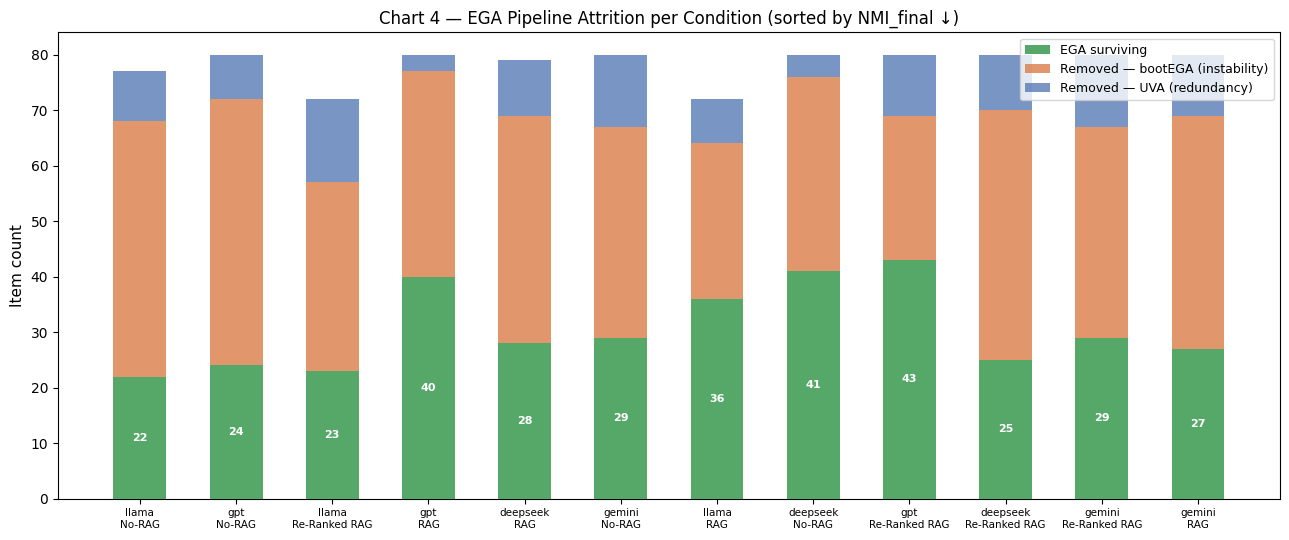

Saved → outputs/chart_c4_attrition.jpeg


In [34]:
cond_order = list(m.sort_values("final_nmi_pct", ascending=False)["Condition"])

uva_rm   = []
boot_rm  = []
survived = []

for cond in cond_order:
    row = m[m["Condition"] == cond].iloc[0]
    uva_rm.append(int(row["items_start"] - row["items_after_uva"]))
    boot_rm.append(int(row["items_after_uva"] - row["items_after_boot"]))
    survived.append(int(row["items_after_boot"]))

labels = [c.replace(" × ", "\n") for c in cond_order]
x = np.arange(len(cond_order))
w = 0.55

fig, ax = plt.subplots(figsize=(13, 5.5))

b_surv = ax.bar(x, survived, w, label="EGA surviving",      color="#55A868", zorder=3)
b_boot = ax.bar(x, boot_rm,  w, bottom=survived,            label="Removed — bootEGA (instability)",
                color="#DD8452", alpha=0.85, zorder=3)
b_uva  = ax.bar(x, uva_rm,   w,
                bottom=[s+b for s,b in zip(survived, boot_rm)],
                label="Removed — UVA (redundancy)",  color="#4C72B0", alpha=0.75, zorder=3)

# Annotate surviving count inside bar
for xi, val in zip(x, survived):
    ax.text(xi, val/2, str(val), ha="center", va="center", fontsize=8,
            fontweight="bold", color="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel("Item count", fontsize=11)
ax.set_title("Chart 4 — EGA Pipeline Attrition per Condition (sorted by NMI_final ↓)", fontsize=12)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("outputs/chart_c4_attrition.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/chart_c4_attrition.jpeg")


### Radar Profile per Model

Six axes (normalized 0–1):
**DAAL accuracy · mean disc · EGA NMI final · EGA match% · items retained · neg-disc rate (inverted)**.Three lines = three RAG conditions.

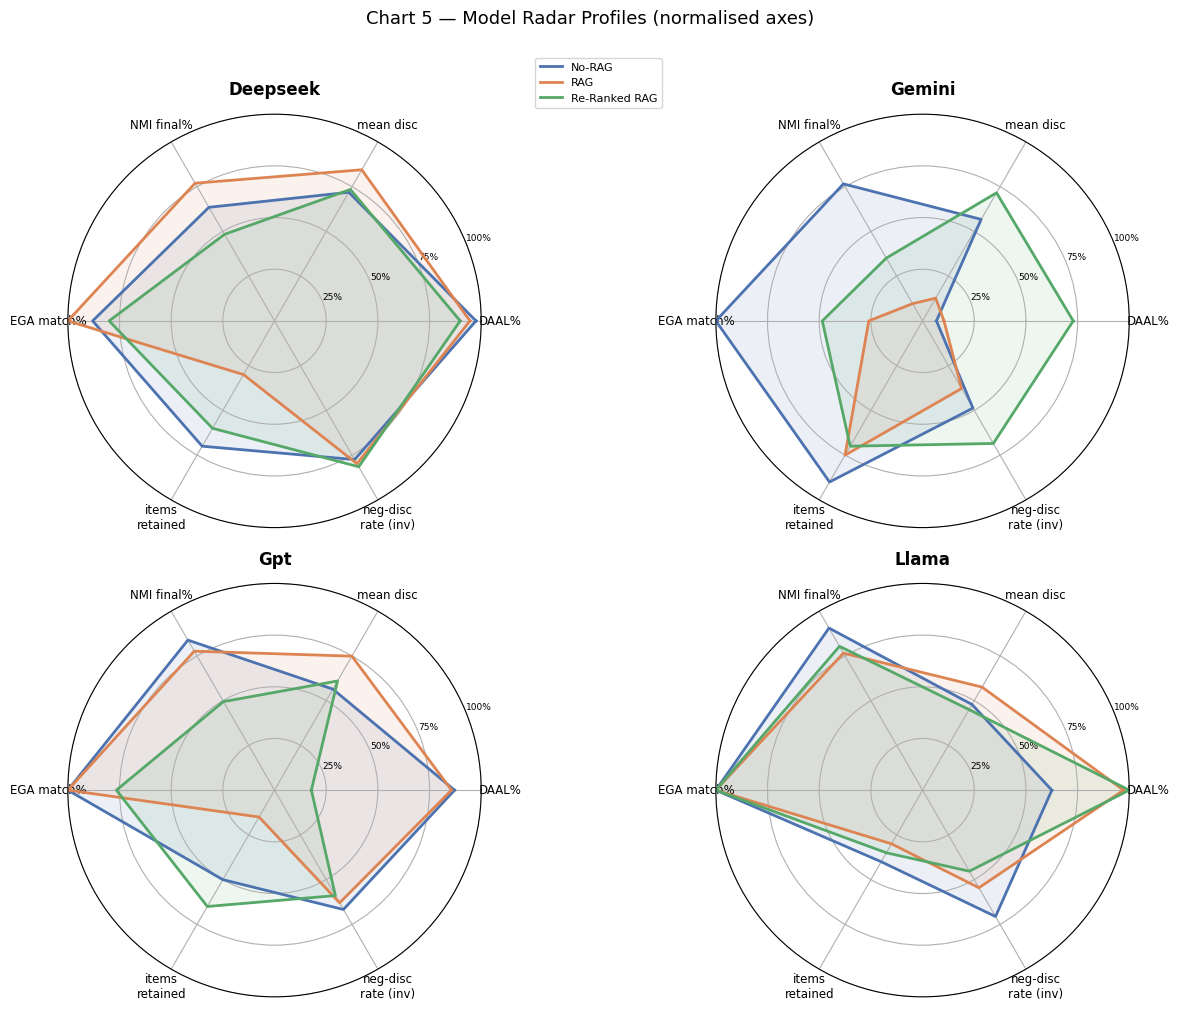

Saved → outputs/chart_c5_radar.jpeg


In [35]:
import matplotlib.pyplot as plt
import numpy as np

models    = ["deepseek", "gemini", "gpt", "llama"]
rag_conds = ["No-RAG", "RAG", "Re-Ranked RAG"]
rag_colors = {"No-RAG": "#4C72B0", "RAG": "#DD8452", "Re-Ranked RAG": "#55A868"}

axes_labels = ["DAAL%", "mean disc", "NMI final%", "EGA match%",
               "items\nretained", "neg-disc\nrate (inv)"]
N = len(axes_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

# Normalisation bounds (manual, sensible range)
norm_bounds = {
    "DAAL_acc_after":  (45, 100),
    "mean_disc_after": (0.07, 0.14),
    "final_nmi_pct":   (25, 80),
    "pct_match":       (80, 100),
    "n_final":         (60, 80),      # items retained (EFA final)
    "neg_disc_inv":    (0.7, 1.0),    # 1 - n_neg_disc/n_final
}

def _norm(val, lo, hi):
    return max(0, min(1, (val - lo) / (hi - lo)))

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

for ai, model in enumerate(models):
    ax = axes[ai]
    for rag in rag_conds:
        cond_key = f"{model} × {rag}"
        row = m[m["Condition"] == cond_key]
        if row.empty:
            continue
        r = row.iloc[0]
        neg_inv = 1 - (r["n_neg_disc"] / r["n_final"]) if r["n_final"] > 0 else 1

        vals = [
            _norm(r["DAAL_acc_after"],  *norm_bounds["DAAL_acc_after"]),
            _norm(r["mean_disc_after"], *norm_bounds["mean_disc_after"]),
            _norm(r["final_nmi_pct"],   *norm_bounds["final_nmi_pct"]),
            _norm(r["pct_match"],       *norm_bounds["pct_match"]),
            _norm(r["n_final"],         *norm_bounds["n_final"]),
            _norm(neg_inv,             *norm_bounds["neg_disc_inv"]),
        ]
        vals += vals[:1]
        ax.plot(angles, vals, color=rag_colors[rag], lw=2, label=rag)
        ax.fill(angles, vals, color=rag_colors[rag], alpha=0.10)

    ax.set_thetagrids(np.degrees(angles[:-1]), axes_labels, fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25%","50%","75%","100%"], fontsize=6.5)
    ax.set_title(model.capitalize(), fontsize=12, fontweight="bold", pad=14)
    if ai == 0:
        ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.15), fontsize=8)

fig.suptitle("Chart 5 — Model Radar Profiles (normalised axes)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/chart_c5_radar.jpeg", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/chart_c5_radar.jpeg")


---
## Human Review Item Table

Produces the final item set for expert rating.

**Inclusion criteria:**
- Conditions: Priority-1 only (Llama × No-RAG, DeepSeek × No-RAG, GPT × RAG)
- `disc_score ≥ 0.12` (excludes near-zero and wrong-direction discriminators)
- Cross-condition deduplication: greedy cosine similarity ≥ 0.75 → keep item from higher-priority condition

**Excluded conditions:** Gemini × No-RAG, Gemini × RAG, GPT × Re-Ranked RAG

Output: `outputs/human_review_items.csv` (~89 items, ~50 CI / ~39 PE)

In [37]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
from IPython.display import display
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

DISC_THRESHOLD  = 0.12   # minimum discrimination score
DEDUP_THRESHOLD = 0.75   # max cosine sim allowed between kept items
P1_CONDITIONS   = {"llama × No-RAG", "deepseek × No-RAG", "gpt × RAG"}
PRIORITY_ORDER  = {"llama × No-RAG": 1, "deepseek × No-RAG": 2, "gpt × RAG": 3}

bank = pd.read_csv("outputs/final_item_bank.csv")

# ── Filter to P1 conditions + disc threshold ──────────────────────────────────
pool = bank[
    bank["Condition"].isin(P1_CONDITIONS) &
    (bank["disc_score"] >= DISC_THRESHOLD)
].copy()
pool["priority"] = pool["Condition"].map(PRIORITY_ORDER)
pool = pool.sort_values(["priority", "disc_score"], ascending=[True, False]).reset_index(drop=True)

# ── Embed & deduplicate across conditions ─────────────────────────────────────
sbert = SentenceTransformer("all-MiniLM-L12-v2")
embs  = sbert.encode(pool["Item_Text"].tolist(), show_progress_bar=True, batch_size=64)
sim   = cosine_similarity(embs)

kept_idx = []
for i in range(len(pool)):
    if not kept_idx or sim[i, kept_idx].max() < DEDUP_THRESHOLD:
        kept_idx.append(i)

review = (pool.iloc[kept_idx]
          [["Scale", "Item_Text", "Condition", "disc_score"]]
          .sort_values(["Scale", "disc_score"], ascending=[False, False])
          .reset_index(drop=True))
review.index += 1   # 1-based numbering for raters

n_ci = int((review["Scale"] == "Consistency of Interest").sum())
n_pe = int((review["Scale"] == "Perseverance of Effort").sum())
print(f"Final pool: {len(review)} items  (CI={n_ci}, PE={n_pe})")
print(f"Removed as near-duplicates: {len(pool) - len(review)}")

# ── Display plain list ────────────────────────────────────────────────────────
for scale in ["Consistency of Interest", "Perseverance of Effort"]:
    sub = review[review["Scale"] == scale]
    print(f"\n{'─'*60}")
    print(f"{scale}  ({len(sub)} items)")
    print(f"{'─'*60}")
    for idx, row in sub.iterrows():
        print(f"  {idx:3d}. [{row['disc_score']:.3f}]  {row['Item_Text']}")

# ── Save ──────────────────────────────────────────────────────────────────────
review["cosine_sim"] = pool.iloc[kept_idx]["cosine_sim"].values
review.to_csv("outputs/human_review_items.csv")
print("\nSaved → outputs/human_review_items.csv")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8196.34it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2/2 [00:00<00:00,  5.34it/s]

Final pool: 89 items  (CI=50, PE=39)
Removed as near-duplicates: 13

────────────────────────────────────────────────────────────
Consistency of Interest  (50 items)
────────────────────────────────────────────────────────────
   40. [0.309]  I resist the urge to frequently switch my primary focus.
   41. [0.297]  When I am focused on a main aim, I rarely let my attention wander.
   42. [0.280]  I am intentional about developing a singular ambition.
   43. [0.269]  I tend not to change my main interest for a different one.
   44. [0.268]  I am single-minded in my professional aspirations.
   45. [0.244]  Constantly changing my focus helps keep my mind sharp.
   46. [0.241]  My focus remains unwavering on my primary objectives.
   47. [0.238]  Exploring various interests is more fun than focusing on one.
   48. [0.235]  Devoting myself to a single cause is crucial for achieving success.
   49. [0.232]  My primary interest usually absorbs my thoughts first.
   50. [0.228]  My core intere